In [15]:
import sys
import numpy as np
import matplotlib as mplt
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
import random
import math
import copy
from typing import Annotated, Any, Callable
from pydantic import BaseModel, Field, WithJsonSchema
import pydantic
import numbers
import cv2

from PIL import Image

from numpy.lib.stride_tricks import sliding_window_view
from typing import Any, Callable, Dict, List, Optional, Sequence, Tuple, Union


In [126]:
%load_ext autoreload
%autoreload 2

import sys
for p in ['../../../../src']:
    if p not in sys.path:
        sys.path.append(p)
        
import spikeml as sml
from spikeml.utils.nb_util import xdisplay, Markup
from spikeml.core.signal import signal_dc, signal_pulse, encode1_onehot, encode_onehot, signal_ranges, mean_per_input
from spikeml.core.ngram import build_ngram, ngram_find, ngram_msample, print_ngrams

from spikeml.plot.plot_util import plot_hist, plot_data, plot_lidata, plot_input, plot_xt, plot_mt, plot_spikes, imshow_matrix, imshow_nmatrix
from spikeml.core.params import Params, LayerParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams

from spikeml.core.params import Params, LayerParams, NNParams, ConnectorParams, SpikeParams, SSensorParams, SNNParams, SSNNParams
from spikeml.ui.ipywidgets_ui import ui
from spikeml.utils.widgets import _tqdm

from spikeml.core.matrix import matrix_split, normalize_matrix, _mult, cmask, cmask2, matrix_init, matrix_init2
from spikeml.core.monitor import Monitor

from spikeml.core.spikes import pspike, spike
from spikeml.core.base import Component, Module, Fan, Composite, Chain
from spikeml.core.layer import Layer, SimpleLayer, LinearLayer, NormalizeLayer, ThresholdLayer, BinaryThresholdLayer
from spikeml.core.snn import SNN, SSNN, DSSNN
from spikeml.core.sensor import SSensor
from spikeml.core.connector import Connector, LinearConnector, RateConnector, LIConnector, LIConnector2
from spikeml.core.chain import make_snn_chain, make_ssnn_chain, chain_validate

from spikeml.core.feedback import compute_error, xcompute_error, compute_sg, FeedbackAdapter

from spikeml.datasets.dataset import SimpleDataset, DataLoader
from spikeml.datasets.encoder import one_hot
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph, glyph_dataset, show_all_glyph_txs

from spikeml.core.runner import Context, DataRunner, InferenceRunner, run, nrun, Context, run_with, run_with_feedback


from spikeml.core.sensor_monitor import SSensorMonitor
from spikeml.core.sensor_viewer import SSensorMonitorViewer
from spikeml.core.layer_monitor import LayerMonitor
from spikeml.core.connector_monitor import ConnectorMonitor, LIConnectorMonitor
from spikeml.core.snn_monitor import SNNMonitor, SSNNMonitor
from spikeml.core.layer_viewer import LayerMonitorViewer
from spikeml.core.snn_viewer import SNNMonitorViewer, SSNNMonitorViewer
from spikeml.core.connector_viewer import ConnectorMonitorViewer, LIConnectorMonitorViewer
from spikeml.core.feedback_viewer import ErrorMonitorViewer

from spikeml.core.snn_stats import connector_stats, htest_connections, htest_connector_identity
from spikeml.core.snn_stats_viewer import plot_snn_stats

from spikeml.core.optimize import make_params_spec, vec2dic, setattrs, params_search, set_all_attrs

from spikeml.cv.img_util import show_kmaps, show_tiles, show_kernels, show_kernels_
from spikeml.utils.vector import normalize, normalize_all
from spikeml.utils.img_util import show_img, show_imgs, cv_bgr2rgb, mshow
from  spikeml.core.metrics import eval, print_pred


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [17]:
SEED=37
random.seed(SEED)
np.random.seed(SEED)
np.set_printoptions(edgeitems=3, infstr='inf', linewidth=120, nanstr='nan', precision=4, suppress=True, threshold=1000, formatter=None)


## Unsupervised Convnet

[0 1]
[<Glyph.SLASH: 10>, <Glyph.BACKSLASH: 11>]


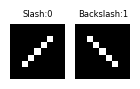

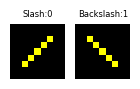

['Slash', 'Backslash']
['Slash', 'Backslash']


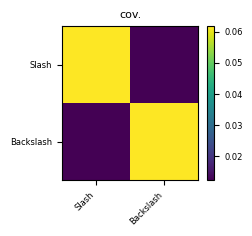

(2, 2)


,Slash,Backslash
Slash,0.061728,0.012346
Backslash,0.012346,0.061728


In [18]:
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs

gg = [#Glyph.FILL, 
    #Glyph.VSLINE, Glyph.VLINE, Glyph.HSLINE, Glyph.HLINE, Glyph.PLUS, Glyph.CROSS, Glyph.SLASH, Glyph.BACKSLASH,
    Glyph.CORNER_TL, Glyph.CORNER_TR, Glyph.CORNER_BL, Glyph.CORNER_BR,
    #Glyph.SQUARE, Glyph.BLOCK, Glyph.TRIANGLE, Glyph.INV_TRIANGLE, Glyph.CIRC,
    #Glyph.LEFT, Glyph.RIGHT, Glyph.TOP, Glyph.BOTTOM,   
    #Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3
    ] 
    
gg = [
    #Glyph.VLINE2, Glyph.HLINE2,
      Glyph.SLASH,  Glyph.BACKSLASH, 
      #Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3
    ]
#gg = [Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3]

glyphsN = xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, shape=(9,9), color=(255, 255, 0), unique=True, shuffle=False,  txs=False)
glyphsNc = xx_c, yy_c, labels_c, dd_c = glyph_dataset(len(gg), gg=gg, shape=(9,9,3), color=(255, 255, 0), unique=True, shuffle=False, txs=False)

print(yy)
print(labels)

#xx = normalize_all(xx, 2)
#print(xx[0])
_=show_imgs(xx, ncols=min(10, xx.shape[0]), figsize=(len(gg),1), pad=.2, title_size=6,  titles=[ f"{dd[i]['id']}:{dd[i]['label']}" for i in range(0, len(dd))])
_=show_imgs(xx_c, ncols=min(10, xx.shape[0]), figsize=(len(gg),1),  pad=.2, title_size=6,  titles=[ f"{dd_c[i]['id']}:{dd_c[i]['label']}" for i in range(0, len(dd_c))])


xx__ = xx.reshape(xx.shape[0], -1)
sim = (xx__ @ xx__.T)/xx__.shape[-1]
labels_ = [str(label) for label in labels ]
mshow(sim, title='cov.', figsize=(2.2,2), colorbar=True, row_names=labels_, col_names=labels_)
print(sim.shape)
#print(sim)
df = pd.DataFrame(sim, columns=gg, index=gg)
display(df)


[[0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 0.]]


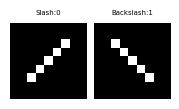

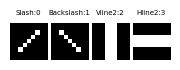

In [144]:
def _test_dataset2():
    gg = [Glyph.SLASH, Glyph.BACKSLASH]
    xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, shape=(9,9), color=(255, 255, 0), unique=True, shuffle=False,  txs=False)
    return  xx, yy, labels 

def _test_dataset2b():
    gg = [Glyph.SLASH, Glyph.VLINE2]
    xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, shape=(9,9), color=(255, 255, 0), unique=True, shuffle=False,  txs=False)
    return  xx, yy, labels 

def _test_dataset():
    return _test_dataset2()

def _test_dataset4():
    gg = [Glyph.SLASH, Glyph.BACKSLASH, Glyph.VLINE2, Glyph.HLINE2]
    xx, yy, labels, dd = glyph_dataset(len(gg), gg=gg, shape=(9,9), color=(255, 255, 0), unique=True, shuffle=False,  txs=False)
    return  xx, yy, labels 

def _test_kernels4():
    kk = [Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3]
    K=3
    M = np.array([glyph(g, (K,K)) for g in kk])
    return M

def _test_kernels2b():
  return np.array([[[-1,-1,1],
                    [-1,1,-1],
                    [1,-1,-1]],
                    [[1,1,1],
                    [1,1,1],
                    [1,1,1]]])

xx, yy, labels = _test_dataset2()
print(xx[0])
_=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])
xx, yy, labels = _test_dataset4()
_=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])



x0t: (3, 3, 3, 3)


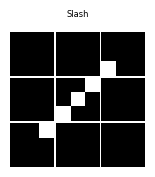

----------
x0t_c: (3, 3, 3, 3, 3)


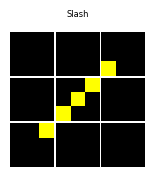

----------
xx: (4, 9, 9)
xt: (4, 3, 3, 3, 3)


IndexError: list index out of range

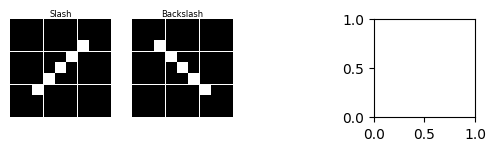

In [148]:
from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph_dataset, show_all_glyph_txs
from spikeml.utils.img_util import show_img, show_imgs, cv_bgr2rgb, mshow
from spikeml.cv.img_util import show_kmaps, show_tiles, show_kernels, show_kernels_

def tiles(x, K, stride=None, batch=None, channels=False, channels_last=False):
    if not isinstance(K, tuple):
        K = (K, K)
    if batch is None:
        batch = len(x.shape)>2  if not channels else len(x.shape)>3
    if not channels: 
        if batch:
            axis = (1,2)
        else:
            axis = (0, 1)
    else:
        if batch:
            axis = (1,2) if channels_last else (2,3)
        else:
            axis = (0, 1) if channels_last else (1,2)

    tiles = sliding_window_view(x, K, axis=axis)
    if stride==None:
        stride = K
    if not isinstance(stride, tuple):
        stride = (stride, stride)
    if batch:
        if not channels:
            tiles = tiles[:, ::stride[0], ::stride[1], :, :]
        else:
            tiles = tiles[:, ::stride[0], ::stride[1], :, :, :]
    else:
        if not channels:
            tiles = tiles[::stride[0], ::stride[1], :, :]
        else:
            tiles = tiles[::stride[0], ::stride[1], :, :, :]
            
    if channels and channels_last:
        if batch:
            tiles = tiles.transpose(0, 1, 2, 4, 5, 3)
        else:
            tiles = tiles.transpose(0, 1, 3, 4, 2)
    return tiles


K=(3,3)
x0t=tiles(xx[0], K, channels_last=True)
print('x0t:', x0t.shape)
show_tiles(x0t, titles=labels_[0], batch=False, normalize=False)
print('-'*10)

x0t_c=tiles(xx_c[0], K, channels=True, channels_last=True)
print('x0t_c:', x0t_c.shape)
show_tiles(x0t_c, titles=labels_[0], batch=False)

print('-'*10)

print('xx:', xx.shape)
K = xx.shape[1]//3
xt=tiles(xx, K, channels_last=True)
print('xt:', xt.shape)
#show_tiles(xt, titles=labels_, normalize=False)
show_tiles(xt, titles=labels_, normalize=False, subplots=True)

print('-'*10)
xt_c=tiles(xx_c, K, channels=True, channels_last=True)
print('xt_c:', xt_c.shape)
show_tiles(xt_c, titles=labels_, subplots=True)


M: (4, 3, 3)
Mc: (4, 3, 3, 3)
Mct: (4, 3, 3, 3)


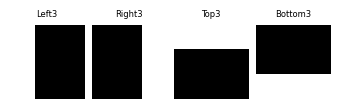

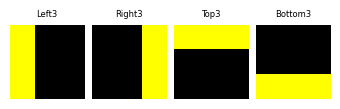

In [20]:
#Glyph.VSLINE, Glyph.VLINE, Glyph.HSLINE, Glyph.HLINE, Glyph.PLUS, Glyph.CROSS, Glyph.SLASH, Glyph.BACKSLASH,
kk = [Glyph.VLINE, Glyph.HLINE,  Glyph.SLASH, Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3]
kk = [Glyph.LEFT3, Glyph.RIGHT3, Glyph.TOP3, Glyph.BOTTOM3]
K=3
M = np.array([glyph(g, (K,K)) for g in kk])
Mc = np.array([glyph(g, (K,K,3), color=(255,255,0)) for g in kk])
Mct = np.array([glyph(g, (K,K,3), color=(255,255,0)).transpose((2,0,1)) for g in kk])

Mlabels = [str(g) for g in kk]
#print(M)
print('M:', M.shape)
print('Mc:', Mc.shape)
print('Mct:', Mct.shape)
show_kernels(M, pad=0.1, figsize=(M.shape[0], 1), titles=Mlabels)
show_kernels(Mc, pad=0.1, figsize=(Mc.shape[0], 1), titles=Mlabels)


In [ ]:
#from spikeml.datasets.cv.glyph import Glyph, make_glyphs, show_glyphs, make_glyph, glyph, glyph_dataset, show_all_glyph_txs

def conv2d(X, K, batch=None, channels=False, channels_last=False, debug=False):
    """
    X: (N, C, H, W)
    K: (F, C, kH, kW)
    """
    if batch is None:
        batch = len(X.shape)>2  if not channels else len(X.shape)>3

    if debug:
        print('X:', X.shape, '; K:', K.shape, 'batch:', batch, '; channels:', channels, '; channels_last:', channels_last))

    if not channels:   
        F, kH, kW = K.shape
        patches = tiles(X, (kH, kW), batch=batch, channels=channels, channels_last=channels_last)
        # no batch: (H, W, kH, kW)
        # batch:    (N, H, W, kH, kW

        if not batch: #H, W = X.shape            
            y_ = np.tensordot(patches, K, axes=((2,3), (1,2)))
            y = np.moveaxis(y_, -1, 0) # (F, H, W)
        else: #N, H, W = X.shape
            y_ = np.tensordot(patches, K, axes=((3,4), (1,2)))
            y = np.moveaxis(y_, -1, 1) # (N, F, H, W)
        return y,patches
    else:
        F, C, kH, kW = K.shape
        patches = tiles(X, (kH, kW), batch=batch, channels=channels, channels_last=channels_last)
        if not batch:
            if channels_last:
                axes=((2,3,4), (2,3,1)) # X: (H, W, C) ; patches: (H, W, kH, kW, C)
            else:
                axes=((2,3,4),(1,2,3)) # X: (C, H, W); patches: (C, H, W, kH, kW)
            y_ = np.tensordot(patches, K, axes=axes) # (H, W, F)
            y = np.moveaxis(y_, -1, 0)     # (F, H, W)
        else:
            if channels_last:
                axes=((5,3,4),(1,2,3)) #X: (N, H, W, C); patches: (N, H, W, kH, kW, C)
            else:                
                axes=((3,4,5),(1,2,3)) # X: (N, C, H, W); patches: (N, C, H, W, kH, kW)
            y_ = np.tensordot(patches, K, axes=axes)
            y = np.moveaxis(y_, -1, 1) # (N, F, H, W)

    if debug:
        print('patches:', patches.shape, '; y_:', y_.shape, '; y:', y.shape)

    return y,patches

def test_title():
    print(X_.shape)
    Xs=tiles(X_[0], K=9, S=9)
    print(Xs.shape)


M: (2, 3, 3)
batch: False ; channels: False ; channels_last: True
X: (9, 9) ; K: (2, 3, 3)
ym: (2, 3, 3)


,,


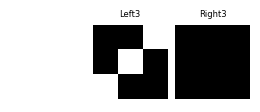

,,,,


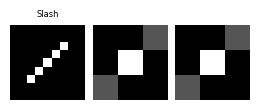

In [112]:
print('M:', M.shape)
ym,_ = conv2d(xx[0], M, debug=True, channels_last=True)
print('ym:', ym.shape)
show_kmaps(xx[0], ym, labels_[0], M, Mlabels, batch=False, debug=True)


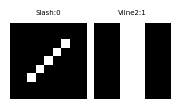

xx_: (2, 9, 9)


-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617


ym: (2, 3, 3)


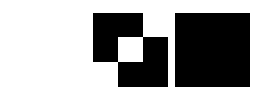

,,,,


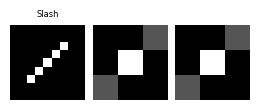

-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333


ym: (2, 3, 3)


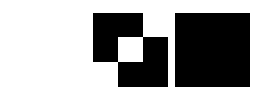

,,,,


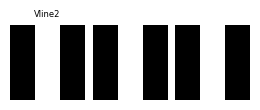

----------------------------------------


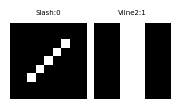

xx_: (2, 9, 9)


-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333


ym: (2, 2, 3, 3)


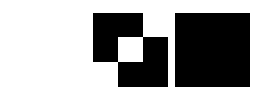

,,,,


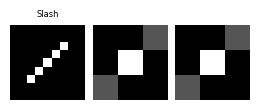

--------------------


,,,,


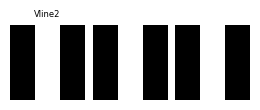

--------------------


In [118]:
def test_conv2d():
  M = np.array([[[0,0,1],
                  [0,1,0],
                  [1,0,0]],
                [[1,1,1],
                [1,1,1],
                [1,1,1]]])

  xx, yy, labels = _test_dataset2b()
  _=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])

  #xx_ = NormalizeLayer()(xx, Context(batch=True))
  xx_ = LayerNorm(mean_only=True, gamma=1, params=LayerParams(vmin=-1, vmax=1))(xx, Context(batch=True))
  print('xx_:', xx_.shape)
  for i in range(xx.shape[0]):
    xdisplay(xx_[i])
    ym,xt = conv2d(xx_[i], M, batch=False)
    print('ym:', ym.shape)
    show_kmaps(xx_[i], ym, labels[i], conv.M.M, batch=False, debug=True, normalize=True)    

def test_conv2d_batch():
  M = np.array([[[0,0,1],
                  [0,1,0],
                  [1,0,0]],
                [[1,1,1],
                [1,1,1],
                [1,1,1]]])
  xx, yy, labels = _test_dataset2b()
  _=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])
  #xx_ = NormalizeLayer()(xx, Context(batch=True))
  xx_ = LayerNorm(mean_only=True, gamma=1, params=LayerParams(vmin=-1, vmax=1))(xx, Context(batch=True))
  print('xx_:', xx_.shape)
  xdisplay(xx_)
  ym,xt = conv2d(xx_, M, batch=True)
  print('ym:', ym.shape)
  show_kmaps(xx_, ym, labels, conv.M.M, batch=True, debug=True, normalize=True)    

test_conv2d()
print('-'*40)
test_conv2d_batch()


0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,1,0,0,,,0,0,0,0,0,0,1,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,0,0,1,0,0,0,,,0,0,0,0,0,1,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,0,1,0,0,0,0,,,0,0,0,0,1,0,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,1,0,0,0,0,0,,,0,0,0,1,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,1,0,0,0,0,0,0,,,0,0,1,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0
0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0,,,0,0,0,0,0,0,0,0,0


xx_c[0]: (9, 9, 3) ; Mc: (4, 3, 3, 3)
batch: False ; channels: True ; channels_last: True
X: (9, 9, 3) ; K: (4, 3, 3, 3)
patches: (3, 3, 3, 3, 3) ; y_: (3, 3, 4) ; y: (4, 3, 3)
ym_c: (4, 3, 3)


0,0,0,,,0,0,2,,,0,0,1,,,0,0,0
0,0,0,,,0,2,0,,,0,2,0,,,0,0,0
0,0,0,,,0,0,0,,,0,0,0,,,0,0,0


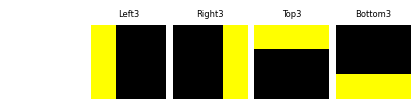

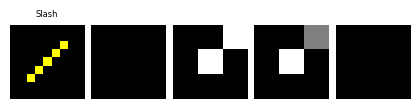

In [ ]:
def test_conv2d_channels():
    xdisplay(Markup('xx_c[0]:', xx_c[0].transpose(2,0,1)))
    print('xx_c[0]:', xx_c[0].shape, '; Mc:', Mc.shape)
    ym_c,_ = conv2d(xx_c[0], Mc, channels=True, channels_last=True, debug=True)
    print('ym_c:', ym_c.shape)
    #xdisplay(*[ Markup(f'{Mlabels[j]}: Mct[{j}]', Mct[j]) for j in range(Mct.shape[0])])
    xdisplay(Markup(f'ym_c', ym_c))
    show_kmaps(xx_c[0], ym_c, labels_[0], Mc, Mlabels, batch=False, debug=False)

test_conv2d_channels()

xx: (2, 9, 9) M: (4, 3, 3)
ym: (2, 4, 3, 3)


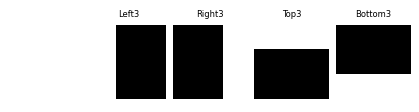

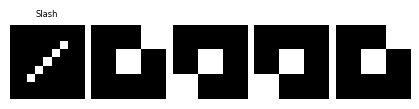

--------------------


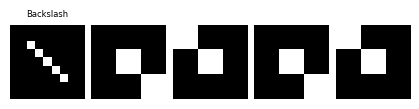

--------------------


In [ ]:
def test_conv2d_batch_channels():
    print('xx:', xx.shape, 'M:', M.shape)
    ym,_ = conv2d(xx, M, channels_last=True, debug=False)
    print('ym:', ym.shape)
    show_kmaps(xx, ym, labels_, M, Mlabels, batch=True, debug=True)
    
test_conv2d_batch_channels()

xx: (2, 9, 9) A: (6, 3, 3)
ym: (6, 3, 3)


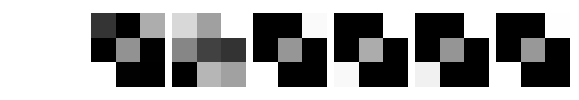

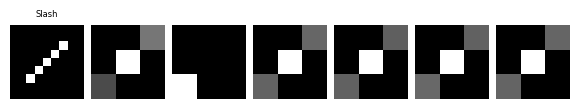

topk: ----------


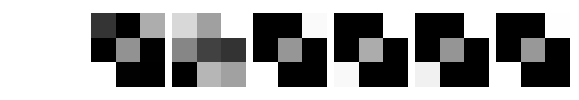

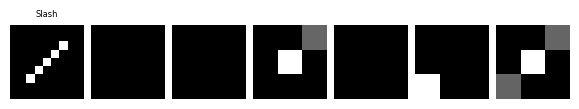

In [25]:
A = np.array([
    [
        [ 0.0171,  -0.0187,  0.098  ],
        [-0.0184,   0.0794, -0.0176 ],
        [ 0.153 ,  -0.0169, -0.0184 ],
    ],
    [
        [ 0.000747,  0.000148,  0.00117 ],
        [-0.00013 , -0.000869, -0.00103 ],
        [-0.00158 ,  0.000381,  0.000154],
    ],
    [
        [-0.399, -0.399,  2.68 ],
        [-0.397,  1.45 , -0.399],
        [ 2.75 , -0.397, -0.397],
    ],
    [
        [-0.266, -0.264,  1.98 ],
        [-0.266,  1.25 , -0.267],
        [ 1.92 , -0.265, -0.265],
    ],
    [
        [-0.381, -0.381,  2.7  ],
        [-0.38 ,  1.42 , -0.382],
        [ 2.52 , -0.38 , -0.381],
    ],
    [
        [-0.529, -0.528,  3.62 ],
        [-0.53 ,  1.96 , -0.529],
        [ 3.65 , -0.529, -0.53 ],
    ],
])

def topk(y, k=2, batch=False):
    if not batch:
        y_ = y.reshape(y.shape[0], -1)
        idx = np.argpartition(y_, -k, axis=0)[-k:, :]
        #print('idx:', idx.shape)
        #print('idx:', idx)
        mask = np.zeros_like(y_, dtype=bool)
        mask[idx, np.arange(y_.shape[1])] = True
        #print(mask)
        y_ = np.where(mask, y_, 0)
        y = y_.reshape(y.shape)
        return y
    else:
        # y: (N, K, D) || (N, K, W, H) 
        y_ = y.reshape(y.shape[0], y.shape[1], -1)
        idx = np.argpartition(y_, -k, axis=1)[:, -k:, :]   # [N, k, D] ; indices of top-k along K (axis=1)
        #print('idx:', idx.shape)
        #print('idx:', idx)
        mask = np.zeros_like(y_, dtype=bool)
        n = np.arange(y_.shape[0])[:, None, None]          # [N,1,1]
        d = np.arange(y_.shape[2])[None, None, :]          # [1,1,D]
        mask[n, idx, d] = True
        #print(mask)
        y_ = np.where(mask, y_, 0)
        y = y_.reshape(y.shape)
        return y
    
def test_topk():
    print('xx:', xx.shape, 'A:', A.shape)
    ym,_ = conv2d(xx[0], A, channels_last=True, debug=False)
    print('ym:', ym.shape)
    show_kmaps(xx[0], ym, labels_[0], A, batch=False, debug=True)
    print('topk:', '-'*10)
    ym_ = topk(ym, 2)
    show_kmaps(xx[0], ym_, labels_[0], A, batch=False, debug=True)

def test_topk_batch():
    print('test_topk_batch:', '-'*40)
    ym,_ = conv2d(xx, A, batch=True, channels_last=True, debug=False)
    show_kmaps(xx, ym, labels_[0], A, batch=True, debug=True)
    print('batch topk:', '-'*10)
    ym_ = topk(ym, 2, batch=True)
    show_kmaps(xx, ym_, labels_, A, batch=True, debug=True)

test_topk()
#test_topk_batch()


xx_c: (2, 9, 9, 3) Mct: (4, 3, 3, 3)
ym_c: (2, 4, 3, 3)


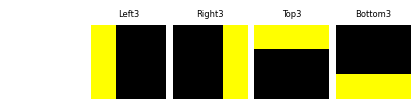

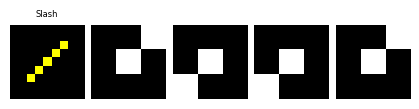

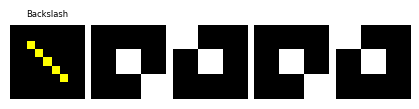

In [26]:
print('xx_c:', xx_c.shape, 'Mct:', Mct.shape)
ym_c,_ = conv2d(xx_c, Mct, batch=True, channels=True, channels_last=True, debug=False)
print('ym_c:', ym.shape)
show_kmaps(xx_c, ym, labels_, Mc, Mlabels, batch=True, debug=False)

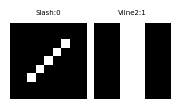

xx_: (2, 9, 9)


-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333


0.185,,,0.185,,,1.19,,,-0.556,,,-0.556,,,0.444,,,1,,,-2,,,1,,,-3,,,6,,,-3
0.185,,,3.19,,,0.185,,,-0.556,,,2.44,,,-0.556,,,1,,,-2,,,1,,,-3,,,6,,,-3
1.19,,,0.185,,,0.185,,,0.444,,,-0.556,,,-0.556,,,1,,,-2,,,1,,,-3,,,6,,,-3


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[4.111111111111111, -1.4444444444444449], [3.0, -3.0]]
ym[center]: [[1.0, 1.0], [-1.0, 1.0]]


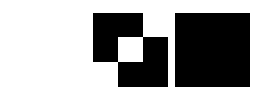

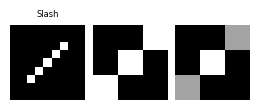

--------------------


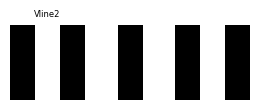

--------------------


In [ ]:
from spikeml.cv.img_util import show_kmaps, show_tiles
#from spikeml.core.layer import LayerNorm
#from spikeml.utils.nb_util import xdisplay, Markup

def test_conv2d_2b():
  M = _test_kernels2b()
  #show_kernels(M, pad=0.1, figsize=(M.shape[0], 1))

  conv = Conv2d(LinearConnector(M), params=NNParams(t_b=5, t_bn=50, e_b=20, vmin=-1, vmax=1))

  xx, yy, labels = _test_dataset2b()
  _=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])

  #xx_ = NormalizeLayer()(xx, Context(batch=True))
  xx_ = LayerNorm(mean_only=True, gamma=1, params=LayerParams(vmin=-1, vmax=1))(xx, Context(batch=True))
  print('xx_:', xx_.shape)
  xdisplay(xx_)
  ym = conv(xx_, Context(batch=True))
  print('ym:', ym.shape)
  print('sum(ym):', ym.sum(axis=(2,3)).tolist())
  print('ym[center]:', ym[:,:,1,1].tolist())

  show_kmaps(xx_, ym, labels, conv.M.M, batch=True, debug=True, normalize=True)    

test_conv2d_2b()
        

In [ ]:
from spikeml.core.layer import bias_update
from spikeml.core.params import NNParams
from spikeml.core.connector import RateConnector
from spikeml.cv.img_util import show_kmaps, show_tiles

class Conv2d(SimpleLayer):
    """
    Conv2d layer.
    
    Attributes:
        M: Connector or matrix
        s, zs: Last Input and spike output.
        y, zy: Last Output potentials and output spikes.
        params: Layer parameters.
        monitor: Optional monitoring object.
        viewer: Optional viewer object.
    """

    def __init__(self,
                 M: Optional[Any] = None,
                 b: Optional[Any] = 0,
                 phase: Optional[Any] = None,
                 params: Optional[Any] = None,
                 auto_sample: bool = False,
                 monitor: Union[bool, Any] = True,
                 viewer: Union[bool, Any] = True,
                 name: Optional[str] = None,
                 callback: Optional[Any] = None) -> None:
        super().__init__(M=M, phase=phase, name=name, auto_sample=auto_sample, callback=callback)
        self.x = None
        self.y = None
        if isinstance(b, numbers.Number):
            b = np.ones((M.shape[0]))*b
        self.b = b
        if params is None:
            params = NNParams()
        self.params = params
        if monitor==True:
            monitor = LayerMonitor(ref=self)
        if viewer==True:
            viewer = LayerMonitorViewer(monitor)
        self.viewer=viewer
        self.monitor=monitor
                
    def propagate(self, x: Union[np.ndarray, Tuple[np.ndarray, np.ndarray]], context: Optional[Any]=None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Propagate input spikes through the network and update neuron potentials.
        
        Args:
        xs: Input array or tuple (x, zs) of vector pair (rate, spikes).

        Returns:
            Tuple containing updated potentials (y) and spikes (zy).
        """
        self.x, _y = x if isinstance(x, tuple) else (x, None)

        batch = self.is_batch(context)
        channels = self.is_channels(context)
        channels_last = self.is_channels_last(context)

        if self.is_propagation(context):                
            #print('x:', x.shape, 'M:', self.M.shape, 'batch:', batch, 'channels:', channels, 'channels_last:', channels_last)
            #print(self.x)
            y, xt = conv2d(self.x, self.M.M, batch=batch, channels=channels, channels_last=channels_last, debug=False)
            #xdisplay(Markup(f'y{y.shape}', y))              
            #xdisplay(Markup(f'xt{xt.shape}', xt))              

            self._y = y
            if self.M.params.topk>0:
                y = topk(y, self.M.params.topk, batch)
                
            #print(xt)
            #print(y)
            self.y = y = np.clip(y, self.params.vmin, self.params.vmax)
            self.xt = xt
            if batch:    
                self.x_ = xt.reshape(-1, np.prod(xt.shape[3:])) # (N,I,J,H,W) -> (N*I*J,K*H*W) ||  (N,I,J,K,H,W) -> (N*I*J,K*H*W) 
                self.y_ = y.transpose(0, 2, 3, 1).reshape(-1, y.shape[1]) # (N, K, I, J) -> (N, I, J, K) -> (N*I*J, K)
                #print('y:', y.shape, '; y_:', self.y_.shape, y.transpose(0, 2, 3, 1).shape)  
            else:
                self.x_ = xt.reshape(-1, np.prod(xt.shape[2:]))  # (I,J,H,W) -> (I*J,K*H*W) ||  (I,J,K,H,W) -> (I*J,K*H*W)
                self.y_ = y.transpose(1, 2, 0).reshape(-1, y.shape[0]) # (K,I,J) -> (I,J,K) -> (I*J,K)
                #print(self.y_)
            if isinstance(self.b, numbers.Number):
                self.b = np.ones(self.y_.shape[1])*self.b
            #print('batch:', batch, '; M:', self.M.shape, 'xt:', self.xt.shape, '; x_:', self.x_.shape, '; y:', self.y.shape, '; y_:', self.y_.shape, '; b:', self.b.shape)
            if self.b is not None:
                self.y_ = self.y_ - self.b
            self.y_ = y_ = np.clip(self.y_, self.params.vmin, self.params.vmax)
            if batch:
                self.y = y = y_.reshape(y.shape[0], y.shape[2], y.shape[3], y.shape[1]).transpose(0, 3, 1, 2)
            else:
                self.y = y = y_.reshape(y.shape[1], y.shape[2], y.shape[0]).transpose(2, 0, 1)

            #self.y = self.y_.reshape(self.y.shape)
            #print('M:', self.M.shape, 'xt:', self.xt.shape, '; x_:', self.x_.shape, '; y:', self.y.shape, '; y_:', self.y_.shape, '; b:', self.b.shape)

        if self.is_learning(context):
            _context = self._get_required_context(context)
            _context.batch = True
            x_ = self.x_ 
            y_ = self.y_
            if hasattr(self.M, 'propagate'):
                #print('M:', self.M.shape, '; xt:', self.xt.shape, '; x_:', x_.shape, '; y:', self.y.shape, '; y_:', y_.shape)                
                self.M.propagate(x_, y_, _context)
            if self.b is not None:
                #xdisplay(Markup('y_', y_)) #.reshape(y_.shape[0], xt.shape[2], xt.shape[3])
                self.b = bias_update(self.b, y_, batch=True, params=self.params)        
                #print('b:', self.b.shape, '-> b:', self.b)                
            
            _context.batch = batch

        return (self.y, x[1]) if isinstance(x, tuple) else self.y

    def _get_required_context(self, context):
        _context = context
        if _context is None:
            if not hasattr(self, '_context'):
                self._context = Context() 
            _context = self._context
        return _context        

    

    def log(self, options: Optional[Dict[str, Any]] = None) -> None:
        #print(f'{self._prefix()}: x={self.x} -> y={self.y}')
        xdisplay(Markup(f'{self._prefix()}.x', self.x), Markup(f'{self._prefix()}.y', self.y)) 
        if self.b is not None:
            print(f'{self._prefix()}: b={self.b}') 
        self.log_connector(options)


In [28]:
A = np.array([
    [[0.0, 0.0, 0.153],
     [0.0, 0.3304, 0.0],
     [0.098, 0.0, 0.0]],

    [[0.0, 0.0, -0.0016],
     [0.0, -0.0013, 0.0],
     [0.0012, 0.0, 0.0]],

    [[0.0, 0.0, 2.75],
     [0.0, 6.88, 0.0],
     [2.68, 0.0, 0.0]],

    [[0.0, 0.0, 1.92],
     [0.0, 5.15, 0.0],
     [1.98, 0.0, 0.0]],

    [[0.0, 0.0, 2.52],
     [0.0, 6.64, 0.0],
     [2.7, 0.0, 0.0]],

    [[ 0, 0, 3.65 ],
     [ 0, 9.23, 0 ],
     [ 3.62, 0, 0, ]]    
])

print(A.shape)  # (5, 3, 3)


print(A.shape)  # (5, 3, 3)
print(A)
A_ = A.transpose(1, 2, 0).reshape(-1, A.shape[0])
#print(A_)
B = A_.reshape(A.shape[1], A.shape[2], A.shape[0]).transpose(2, 0, 1)
print(B)


(6, 3, 3)
(6, 3, 3)
[[[ 0.      0.      0.153 ]
  [ 0.      0.3304  0.    ]
  [ 0.098   0.      0.    ]]

 [[ 0.      0.     -0.0016]
  [ 0.     -0.0013  0.    ]
  [ 0.0012  0.      0.    ]]

 [[ 0.      0.      2.75  ]
  [ 0.      6.88    0.    ]
  [ 2.68    0.      0.    ]]

 [[ 0.      0.      1.92  ]
  [ 0.      5.15    0.    ]
  [ 1.98    0.      0.    ]]

 [[ 0.      0.      2.52  ]
  [ 0.      6.64    0.    ]
  [ 2.7     0.      0.    ]]

 [[ 0.      0.      3.65  ]
  [ 0.      9.23    0.    ]
  [ 3.62    0.      0.    ]]]
[[[ 0.      0.      0.153 ]
  [ 0.      0.3304  0.    ]
  [ 0.098   0.      0.    ]]

 [[ 0.      0.     -0.0016]
  [ 0.     -0.0013  0.    ]
  [ 0.0012  0.      0.    ]]

 [[ 0.      0.      2.75  ]
  [ 0.      6.88    0.    ]
  [ 2.68    0.      0.    ]]

 [[ 0.      0.      1.92  ]
  [ 0.      5.15    0.    ]
  [ 1.98    0.      0.    ]]

 [[ 0.      0.      2.52  ]
  [ 0.      6.64    0.    ]
  [ 2.7     0.      0.    ]]

 [[ 0.      0.      3.65  ]
  [ 0.

In [29]:
from spikeml.core.layer import bias_update
from spikeml.core.params import NNParams
from spikeml.core.connector import RateConnector
from spikeml.cv.img_util import show_kmaps, show_tiles

class ____Conv2d(SimpleLayer):
    """
    Conv2d layer.
    
    Attributes:
        M: Connector or matrix
        s, zs: Last Input and spike output.
        y, zy: Last Output potentials and output spikes.
        params: Layer parameters.
        monitor: Optional monitoring object.
        viewer: Optional viewer object.
    """

    def __init__(self,
                 M: Optional[Any] = None,
                 b: Optional[Any] = 0,
                 phase: Optional[Any] = None,
                 params: Optional[Any] = None,
                 auto_sample: bool = False,
                 monitor: Union[bool, Any] = True,
                 viewer: Union[bool, Any] = True,
                 name: Optional[str] = None,
                 callback: Optional[Any] = None) -> None:
        super().__init__(M=M, phase=phase, name=name, auto_sample=auto_sample, callback=callback)
        self.s = None
        self.y = None
        self.b = b
        if params is None:
            params = NNParams()
        self.params = params
        if monitor==True:
            monitor = LayerMonitor(ref=self)
        if viewer==True:
            viewer = LayerMonitorViewer(monitor)
        self.viewer=viewer
        self.monitor=monitor
                
    def __propagate(self, s: Union[np.ndarray, Tuple[np.ndarray, np.ndarray]], context: Optional[Any]=None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Propagate input spikes through the network and update neuron potentials.
        
        Args:
            s: Input array or tuple (s, zs) of vector pair (rate, spikes).

        Returns:
            Tuple containing updated potentials (y) and spikes (zy).
        """
        self.s, _y = s if isinstance(s, tuple) else (s, None)

        if self.is_propagation(context):    
            self.y,self.xt = self._propagate(self.s, context)
                            
        if self.is_learning(context):
            batch = self.is_batch(context)
            y_ = self.y.mean(axis=tuple(range(2 if batch else 1, self.y.ndim)))
            if self.b is not None:
                print('y_:', y_, '; b:', self.b)
                self.b = bias_update(self.b, y_, batch=batch, params=self.params)        
                print('-> b:', self.b)                
            if hasattr(self.M, 'propagate'):
                xt = self.xt 
                y_ = self.y
                #x_ = self.xt.mean((1,2) if batch else (0,1)) 
                #x_ = x_.reshape(x_.shape[0],-1) if batch else x_.reshape(-1)
                if batch:    
                    x_ = xt.reshape(-1, np.prod(xt.shape[3:])) # (N,I,J,H,W) -> (N*I*J,K*H*W) ||  (N,I,J,K,H,W) -> (N*I*J,K*H*W) 
                    y_ = y_.transpose(0, 2, 3, 1).reshape(-1, y_.shape[3]) # (N, K, I, J) -> (N, I, J, K) -> (N*I*J, K)
                else:
                    x_ = xt.reshape(-1, np.prod(xt.shape[2:]))  # (I,J,H,W) -> (I*J,K*H*W) ||  (I,J,K,H,W) -> (I*J,K*H*W)
                    y_ = y_.transpose(1, 2, 0).reshape(-1, y_.shape[0]) # (K,I,J) -> (I,J,K) -> (I*J,K)
                _context = self._get_required_context(context)
                _context.batch = True                       
                print('M:', M.shape, '; xt:', self.xt.shape, '; x_:', x_.shape, '; y:', self.y.shape, '; y_:', y_.shape)                
                self.M.propagate(x_, y_, _context)
                _context.batch = batch
    
        return (self.y, s[1]) if isinstance(s, tuple) else self.y

        
    def _propagate(self, x, context):
        batch = self.is_batch(context)
        channels = self.is_channels(context)
        channels_last = self.is_channels_last(context)
        
        #print('x:', x.shape, 'M:', self.M.shape)
        _y, xt = conv2d(x, self.M.M, batch=batch, channels=channels, channels_last=channels_last, debug=False)
        y = np.clip(_y, self.params.vmin, self.params.vmax)
        if self.b is not None:
            #print('b:', self.b.shape, '; y:', y.shape)
            _y = y - self.b[:, None, None]
        y = np.clip(_y, self.params.vmin, self.params.vmax)
        #print('_y:', _y.shape, 'y:', y.shape, 'xt:', xt.shape)
        return y,xt
    
    def propagate(self, x: Union[np.ndarray, Tuple[np.ndarray, np.ndarray]], context: Optional[Any]=None) -> Tuple[np.ndarray, np.ndarray]:
        """
        Propagate input spikes through the network and update neuron potentials.
        
        Args:
        xs: Input array or tuple (x, zs) of vector pair (rate, spikes).

        Returns:
            Tuple containing updated potentials (y) and spikes (zy).
        """
        self.x, _y = x if isinstance(x, tuple) else (x, None)

        batch = self.is_batch(context)
        channels = self.is_channels(context)
        channels_last = self.is_channels_last(context)

        if self.is_propagation(context):                
            #print('x:', x.shape, 'M:', self.M.shape)
            y, xt = conv2d(self.x, self.M.M, batch=batch, channels=channels, channels_last=channels_last, debug=False)
            self.y = y = np.clip(y, self.params.vmin, self.params.vmax)
            self.xt = xt
            if batch:    
                self.x_ = xt.reshape(-1, np.prod(xt.shape[3:])) # (N,I,J,H,W) -> (N*I*J,K*H*W) ||  (N,I,J,K,H,W) -> (N*I*J,K*H*W) 
                self.y_ = y.transpose(0, 2, 3, 1).reshape(-1, y.shape[3]) # (N, K, I, J) -> (N, I, J, K) -> (N*I*J, K)
            else:
                self.x_ = xt.reshape(-1, np.prod(xt.shape[2:]))  # (I,J,H,W) -> (I*J,K*H*W) ||  (I,J,K,H,W) -> (I*J,K*H*W)
                self.y_ = y.transpose(1, 2, 0).reshape(-1, y.shape[0]) # (K,I,J) -> (I,J,K) -> (I*J,K)
            if isinstance(self.b, numbers.Number):
                self.b = np.ones(self.y_.shape)*self.b
            print('M:', self.M.shape, 'xt:', self.xt.shape, '; x_:', self.x_.shape, '; y:', self.y.shape, '; y_:', self.y_.shape, '; b:', self.b.shape)
            if self.b is not None:
                self.y_ = self.y_ - self.b
            self.y_ = np.clip(self.y_, self.params.vmin, self.params.vmax)
            self.y = self.y_.reshape(self.y.shape)
            print('M:', self.M.shape, 'xt:', self.xt.shape, '; x_:', self.x_.shape, '; y:', self.y.shape, '; y_:', self.y_.shape, '; b:', self.b.shape)

                            
        if self.is_learning(context):
            x_ = self.x_ 
            y_ = self.y_
            if hasattr(self.M, 'propagate'):
                _context = self._get_required_context(context)
                _context.batch = True                       
                print('M:', self.M.shape, '; xt:', self.xt.shape, '; x_:', x_.shape, '; y:', self.y.shape, '; y_:', y_.shape)                
                self.M.propagate(x_, y_, _context)
                _context.batch = batch

            if self.b is not None:
                print('; b:', self.b)
                self.b = bias_update(self.b, y_, batch=True, params=self.params)        
                print('-> b:', self.b)                
    
        return (self.y, s[1]) if isinstance(s, tuple) else self.y


M: (4, 3, 3)


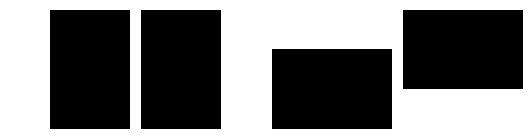

ym: (4, 3, 3)


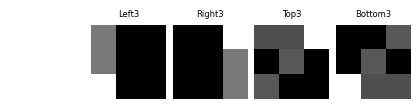

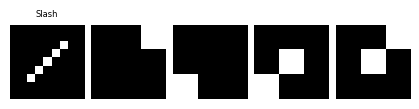

-0.1,-0.1,-0.1,-0.1,-0.1,-0.1,1,-0.1,-0.1
-0.1,-0.1,1,-0.1,-0.1,-0.1,-0.1,-0.1,-0.1
-0.2,-0.2,2,-0.2,0.9,-0.2,0.9,-0.2,-0.2
-0.2,-0.2,0.9,-0.2,0.9,-0.2,2,-0.2,-0.2


b: [0.04 0.04 0.26 0.26]


(Conv2d): b=[0.04 0.04 0.26 0.26]


----------------------------------------
M: (4, 3, 3)
M: (4, 3, 3)


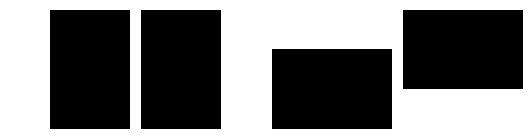

ym: (2, 4, 3, 3)


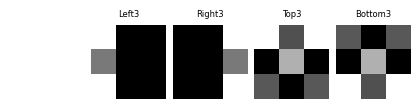

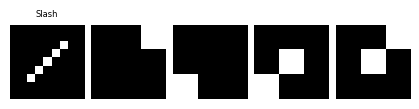

--------------------


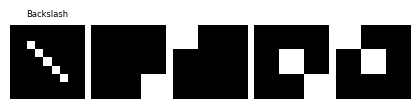

--------------------


0.9,-0.2,-0.2,-0.2,-0.2,-0.2,0.9,-0.2,-0.2
-0.2,-0.2,0.9,-0.2,-0.2,-0.2,-0.2,-0.2,0.9
1.8,-0.4,1.8,-0.4,1.8,-0.4,0.7,-0.4,0.7
0.7,-0.4,0.7,-0.4,1.8,-0.4,1.8,-0.4,1.8


b: [0.08 0.08 0.52 0.52]


(Conv2d): b=[0.08 0.08 0.52 0.52]


In [ ]:
def test_Conv2d():
    xx, yy, labels = _test_dataset()
    M = _test_kernels()
    print('M:', M.shape)
    M_= RateConnector(M.copy(), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=10, cmin=-10, cmax=10, topk=2))
    conv = Conv2d(M_, params=NNParams(t_b=5, t_bn=50, e_b=20))
    #print('xx[0]:', xx[0].shape)
    #print(xx[0])
    show_kernels(conv.M.M)
    ym = conv(xx[0])
    print('ym:', ym.shape)
    show_kmaps(xx[0], ym, labels_[0], conv.M.M, Mlabels, batch=False, debug=True)
    #xdisplay(*Markup('ym:', ym))
    xdisplay(Markup('dM:', conv.M.dM))
    print('b:', conv.b)
    conv.log()

def test_Conv2d_batch():
    xx, yy, labels = _test_dataset()
    M = _test_kernels()    
    print('M:', M.shape)
    M_= RateConnector(M.copy(), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=10, cmin=-10, cmax=10, topk=2))
    print('M:', M_.shape)
    conv = Conv2d(M_, params=NNParams(t_b=5, t_bn=50, e_b=20))
    #print('xx[0]:', xx[0].shape)
    #print(xx[0])
    show_kernels(conv.M.M)
    ym = conv(xx, Context(batch=True))
    print('ym:', ym.shape)
    show_kmaps(xx, ym, labels, conv.M.M, Mlabels, batch=True, debug=True)
    #xdisplay(*Markup('ym:', ym))
    xdisplay(Markup('dM:', conv.M.dM))
    print('b:', conv.b)
    conv.log()

def test_Conv2d_2():
    print('xx:', xx.shape, 'A:', A.shape)
    ym,_ = conv2d(xx[0], A, channels_last=True, debug=False)
    print('ym:', ym.shape)
    show_kmaps(xx[0], ym, labels_[0], A, batch=False, debug=True)

    print('-'*10)
    A_= RateConnector(A.copy(), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=10, cmin=-10, cmax=10))
    print('A:', A_.shape)
    conv = Conv2d(A_)
    #print('xx[0]:', xx[0].shape)
    #print(xx[0])
    ym = conv(xx[0])
    print('ym:', ym.shape)
    show_kmaps(xx[0], ym, labels_[0], conv.M.M, batch=False, debug=True)
    #xdisplay(*Markup('ym:', ym))
    #xdisplay(Markup('dM:', conv.M.dM))
    print('b:', conv.b)
    conv.log()

test_Conv2d()
print('-'*40)
test_Conv2d_batch()


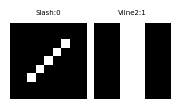

xx_: (2, 9, 9)


-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333


0.185,,,0.185,,,1.19,,,-0.556,,,-0.556,,,0.444,,,1,,,-2,,,1,,,-3,,,6,,,-3
0.185,,,3.19,,,0.185,,,-0.556,,,2.44,,,-0.556,,,1,,,-2,,,1,,,-3,,,6,,,-3
1.19,,,0.185,,,0.185,,,0.444,,,-0.556,,,-0.556,,,1,,,-2,,,1,,,-3,,,6,,,-3


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[6.481481481481481, -2.220446049250313e-16], [0.0, -9.0]]
ym[center]: [[3.0, 2.4444444444444446], [-2.0, 3.0]]


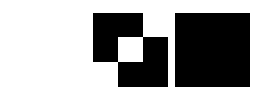

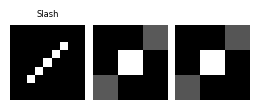

--------------------


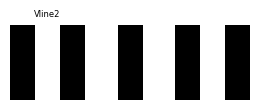

--------------------


In [152]:
def test_Conv2b_batch_2b_fixed():
  M = _test_kernels2b()
  #show_kernels(M, pad=0.1, figsize=(M.shape[0], 1))

  conv = Conv2d(LinearConnector(M), params=NNParams(t_b=5, t_bn=50, e_b=20, vmin=-3, vmax=3))

  xx, yy, labels = _test_dataset2b()
  _=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])

  #xx_ = NormalizeLayer()(xx, Context(batch=True))
  xx_ = LayerNorm(mean_only=True, gamma=1, params=conv.params)(xx, Context(batch=True))
  #xx_ = NormalizeLayer(norm=1)(xx_, Context(batch=True))
  print('xx_:', xx_.shape)
  xdisplay(xx_)
  ym = conv(xx_, Context(batch=True))
  print('ym:', ym.shape)
  print('sum(ym):', ym.sum(axis=(2,3)).tolist())
  print('ym[center]:', ym[:,:,1,1].tolist())

  show_kmaps(xx_, ym, labels, conv.M.M, batch=True, debug=True, normalize=True)    
  
test_Conv2b_batch_2b_fixed()


M: (10, 3, 3)
NNParams:t_b=20,t_bn=30,e_b=2,g=1,e_err=5,vmin=0,vmax=1
NNParams:t_b=5.0,t_bn=50.0,e_b=20.0,g=1,e_err=5,vmin=0,vmax=1


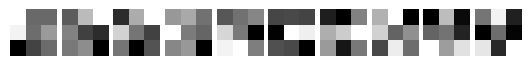

  0%|          | 0/10 [00:00<?, ?it/s]

t: 0


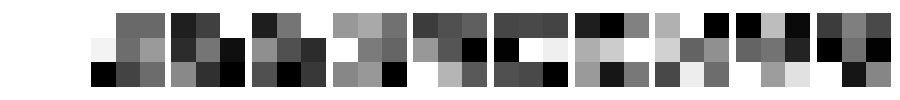

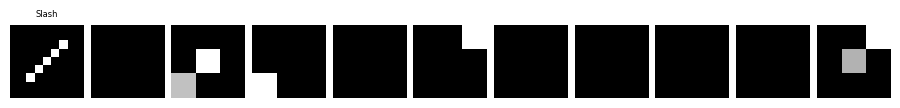

----------
t: 1


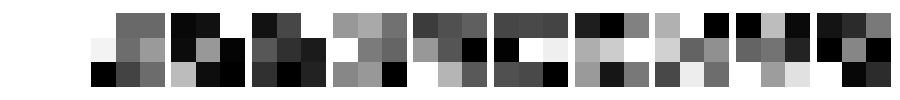

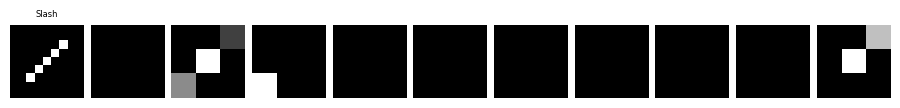

----------
t: 2


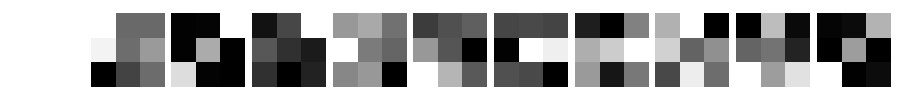

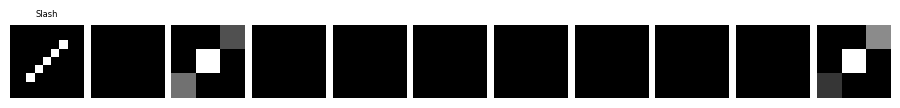

----------
t: 3


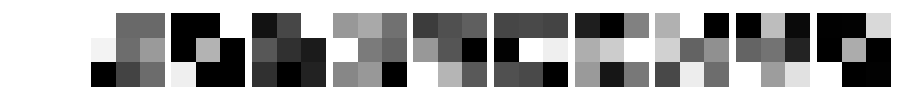

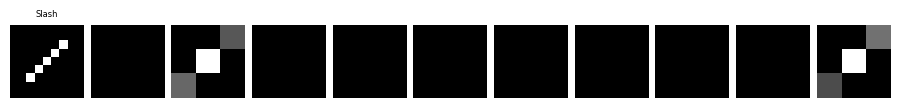

----------
t: 4


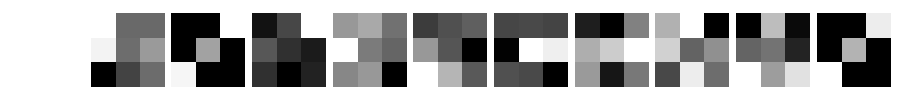

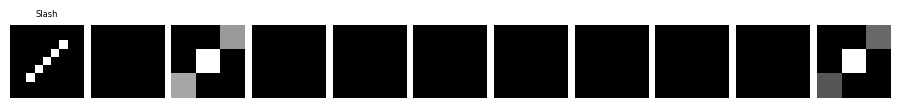

----------
t: 5


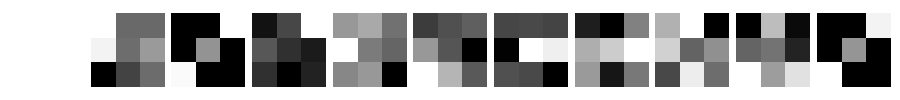

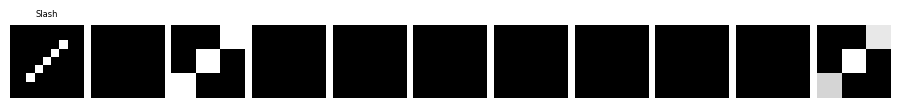

----------
t: 6


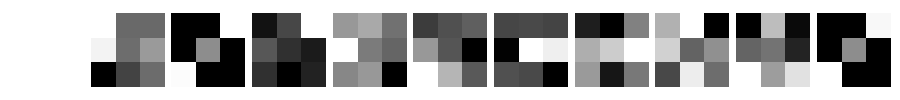

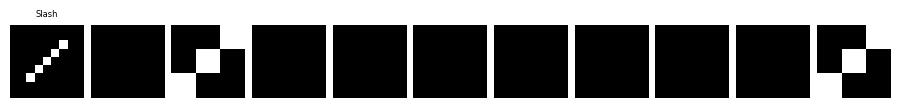

----------
t: 7


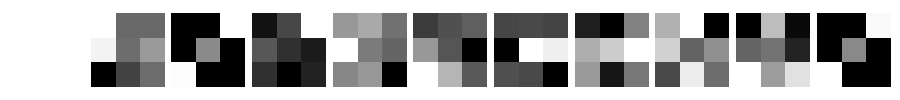

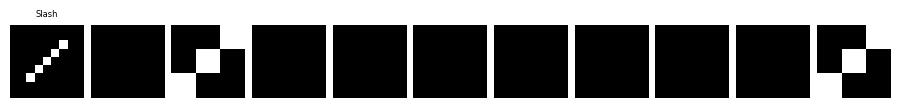

----------
t: 8


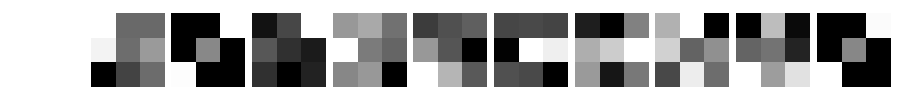

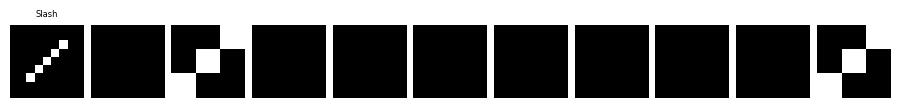

----------
t: 9


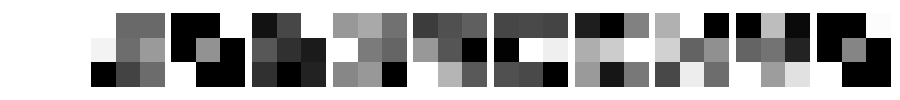

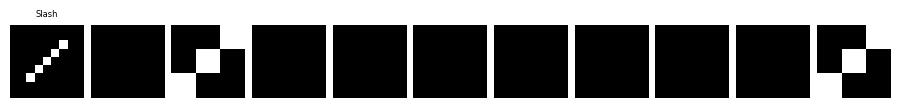

----------


In [40]:

def test_Conv2d_iter():
    I=J=3
    K=10
    M_= RateConnector((K,I,J), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=10, cmin=-10, cmax=10, topk=2))
    print('M:', M_.shape)
    print(NNParams().fmt())
    conv = Conv2d(M_, params=NNParams(t_b=5, t_bn=50, e_b=20))
    print(conv.params.fmt())
    #print('xx[0]:', xx[0].shape)
    #print(xx[0])
    show_kernels(conv.M.M)
    for t in _tqdm(range(0, 10)):
        print('t:', t)
        ym = conv(xx[0])
        #print('ym:', ym.shape)
        show_kmaps(xx[0], ym, labels_[0], conv.M.M, batch=False, debug=False)
        #xdisplay(*Markup('ym:', ym))
        #xdisplay(Markup('dM:', conv.M.dM))
        #print('b:', conv.b)
        #conv.log({'log.connector': False})
        print('-'*10)
        
test_Conv2d_iter()

xx_: (2, 9, 9)


-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333


  0%|          | 0/10 [00:00<?, ?it/s]

t: 0


0.185,,,0.185,,,1.19,,,-0.556,,,-0.556,,,0.444,,,1,,,-2,,,1,,,-3,,,6,,,-3
0.185,,,3.19,,,0.185,,,-0.556,,,2.44,,,-0.556,,,1,,,-2,,,1,,,-3,,,6,,,-3
1.19,,,0.185,,,0.185,,,0.444,,,-0.556,,,-0.556,,,1,,,-2,,,1,,,-3,,,6,,,-3


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[6.481481481481481, -2.220446049250313e-16], [0.0, -9.0]]
ym[center]: [[3.0, 2.4444444444444446], [-2.0, 3.0]]


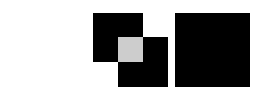

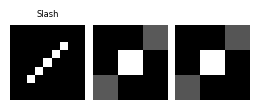

--------------------


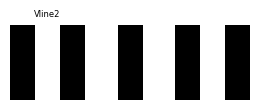

--------------------
----------------------------------------
t: 1


3.68,,,3.68,,,1.6,,,-5.56,,,-5.56,,,4.44,,,19.9,,,-39.8,,,19.9,,,-30,,,60,,,-30
3.68,,,-3.87,,,3.68,,,-5.56,,,24.4,,,-5.56,,,19.9,,,-39.8,,,19.9,,,-30,,,60,,,-30
1.6,,,3.68,,,3.68,,,4.44,,,-5.56,,,-5.56,,,19.9,,,-39.8,,,19.9,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[16.60687866412984, -10.525948377980988], [7.805418104940851, -10.525948377980988]]
ym[center]: [[-3.0, 2.4913505406730034], [-3.0, 2.4913505406730034]]


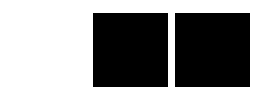

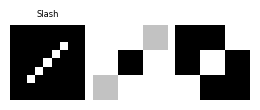

--------------------


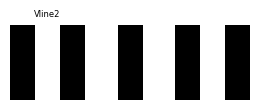

--------------------
----------------------------------------
t: 2


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[0.9480884688119611, -10.418102600105714], [0.9480884688119611, -10.418102600105714]]
ym[center]: [[-3.0, 2.527299133298095], [-3.0, 2.527299133298095]]


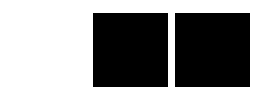

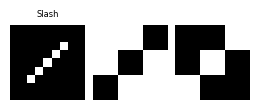

--------------------


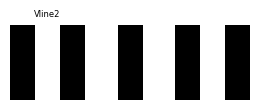

--------------------
----------------------------------------
t: 3


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[1.577022803809447, -10.395590810748196], [1.577022803809447, -10.395590810748196]]
ym[center]: [[-3.0, 2.534803063083934], [-3.0, 2.534803063083934]]


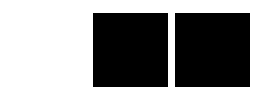

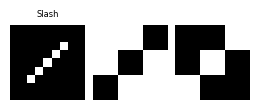

--------------------


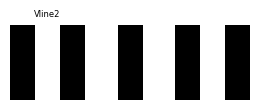

--------------------
----------------------------------------
t: 4


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[2.154903816483193, -10.392263649476678], [2.154903816483193, -10.392263649476678]]
ym[center]: [[-3.0, 2.535912116841107], [-3.0, 2.535912116841107]]


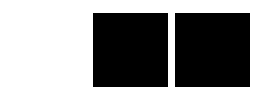

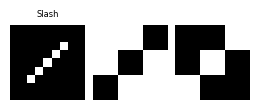

--------------------


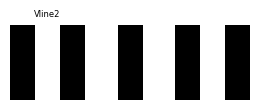

--------------------
----------------------------------------
t: 5


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[2.6628018296396654, -10.391814074078102], [2.6628018296396654, -10.391814074078102]]
ym[center]: [[-3.0, 2.536061975307299], [-3.0, 2.536061975307299]]


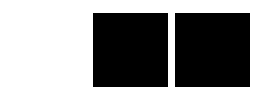

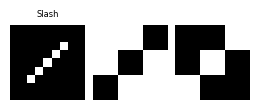

--------------------


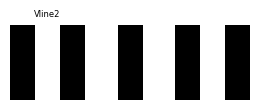

--------------------
----------------------------------------
t: 6


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[3.08319211997369, -10.39175416692476], [3.08319211997369, -10.39175416692476]]
ym[center]: [[-3.0, 2.5360819443584135], [-3.0, 2.5360819443584135]]


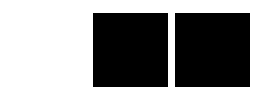

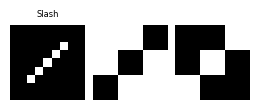

--------------------


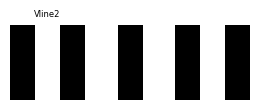

--------------------
----------------------------------------
t: 7


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[3.4061918321588944, -10.39174619926643], [3.4061918321588944, -10.39174619926643]]
ym[center]: [[-3.0, 2.536084600244523], [-3.0, 2.536084600244523]]


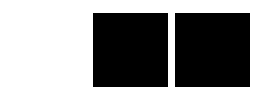

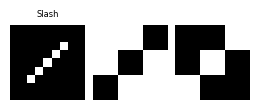

--------------------


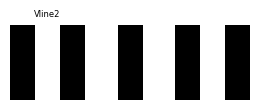

--------------------
----------------------------------------
t: 8


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[3.634658357857246, -10.391745139835157], [3.634658357857246, -10.391745139835157]]
ym[center]: [[-3.0, 2.5360849533882814], [-3.0, 2.5360849533882814]]


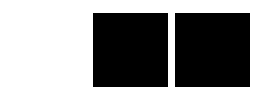

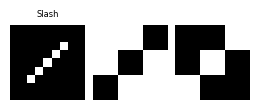

--------------------


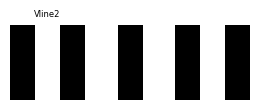

--------------------
----------------------------------------
t: 9


5.56,,,5.56,,,-4.44,,,-5.56,,,-5.56,,,4.44,,,30,,,-60,,,30,,,-30,,,60,,,-30
5.56,,,-24.4,,,5.56,,,-5.56,,,24.4,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30
-4.44,,,5.56,,,5.56,,,4.44,,,-5.56,,,-5.56,,,30,,,-60,,,30,,,-30,,,60,,,-30


-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333
-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,0.938,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.0617,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,-0.333,,,0.667,,,0.667,,,0.667,,,-0.333,,,-0.333,,,-0.333


ym: (2, 2, 3, 3)
sum(ym): [[3.7837409249461915, -10.39174499897108], [3.783740924946192, -10.39174499897108]]
ym[center]: [[-3.0, 2.536085000342974], [-3.0, 2.536085000342974]]


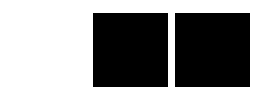

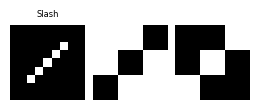

--------------------


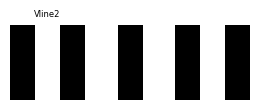

--------------------
----------------------------------------


In [155]:
def test_Conv2b_iter_batch_2b_stable():
    M = _test_kernels2b().astype(float)
    #show_kernels(M, pad=0.1, figsize=(M.shape[0], 1))
    M_= RateConnector(M, params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=10, cmin=-10, cmax=10, topk=2))
    conv = Conv2d(M_, params=NNParams(t_b=5, t_bn=50, e_b=20, vmin=-3, vmax=3))

    xx, yy, labels = _test_dataset2b()
    #_=show_imgs(xx, ncols=xx.shape[0], pad=.1, figsize=(2,1), title_size=5,  titles=[ f"{labels[i]}:{yy[i]}" for i in range(0, len(labels))])
    xx_ = LayerNorm(mean_only=True, gamma=1, params=conv.params)(xx, Context(batch=True))
    #xx_ = NormalizeLayer(norm=1)(xx_, Context(batch=True))
    print('xx_:', xx_.shape)
    xdisplay(xx_)

    for t in _tqdm(range(0, 10)):
        print('t:', t)
        ym = conv(xx_, Context(batch=True))
        print('ym:', ym.shape)
        print('sum(ym):', ym.sum(axis=(2,3)).tolist())
        print('ym[center]:', ym[:,:,1,1].tolist())
        #print('ym:', ym.shape)
        show_kmaps(xx_, ym, labels, conv.M.M, batch=True, debug=True) #, normalize=True
        #xdisplay(*Markup('ym:', ym))
        #xdisplay(Markup('dM:', conv.M.dM))
        #print('b:', conv.b)
        #conv.log({'log.connector': False})
        print('-'*40)
  
test_Conv2b_iter_batch_2b_stable()

In [32]:
#(N, xx[0].size),
Mct_= RateConnector(Mct.copy(), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
print('Mct:', Mct_.shape)
conv_c = Conv2d(Mct_)
ym_c = conv_c(xx_c[0], Context(batch=False, channels=True, channels_last=True))
print('ym_c:', ym_c.shape)
print('dM_c:', conv_c.M.dM)
conv_c.log()

Mct: (4, 3, 3, 3)
ym_c: (4, 3, 3)
dM_c: [[-2. -2. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2.  2.  2. -2. -2. -2. -2. -2. -2. -2.]
 [-2. -2. -2. -2. -2. -2.  2.  2. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2. -2. -2. -2.]
 [-2. -2. -2. -2. -2. -2.  2.  2. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2. -2. -2. -2.]
 [-2. -2. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2.  0.  0. -2. -2. -2. -2.  2.  2. -2. -2. -2. -2. -2. -2. -2.]]


(Conv2d): b=[0. 0. 0. 0.]


xx: (2, 9, 9)
M: (12, 3, 3)
ConnectorParams:g=1,e_err=5,vmin=0,vmax=1,k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=5.0,t_d=10.0,c_in=0,c_out=0,cmin=-10.0,cmax=10.0,mean=0.0,sd=0.001,topk=2
NNParams:t_b=5.0,t_bn=50.0,e_b=20.0,g=1,e_err=5,vmin=0,vmax=1
conv1: 0/10: 0 0 : (9, 9) -> (12, 3, 3)


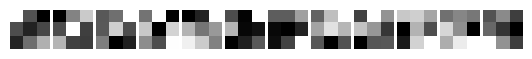

conv1: 0/10: 1 1 : (9, 9) -> (12, 3, 3)


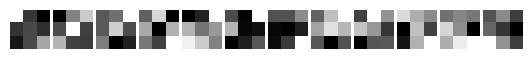

conv1: 1/10: 0 2 : (9, 9) -> (12, 3, 3)


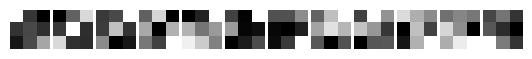

conv1: 1/10: 1 3 : (9, 9) -> (12, 3, 3)


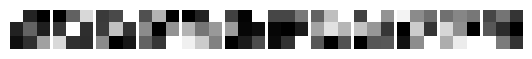

conv1: 2/10: 0 4 : (9, 9) -> (12, 3, 3)


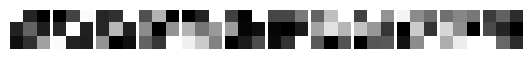

conv1: 2/10: 1 5 : (9, 9) -> (12, 3, 3)


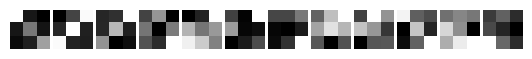

conv1: 3/10: 0 6 : (9, 9) -> (12, 3, 3)


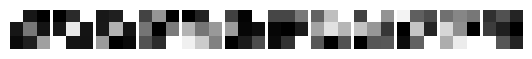

conv1: 3/10: 1 7 : (9, 9) -> (12, 3, 3)


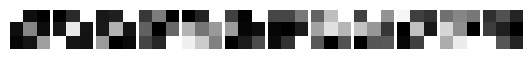

conv1: 4/10: 0 8 : (9, 9) -> (12, 3, 3)


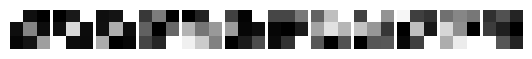

conv1: 4/10: 1 9 : (9, 9) -> (12, 3, 3)


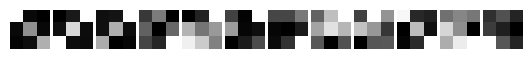

conv1: 5/10: 0 10 : (9, 9) -> (12, 3, 3)


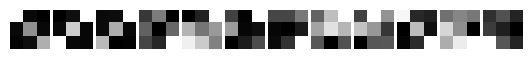

conv1: 5/10: 1 11 : (9, 9) -> (12, 3, 3)


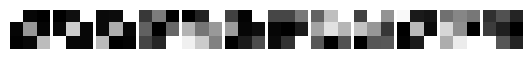

conv1: 6/10: 0 12 : (9, 9) -> (12, 3, 3)


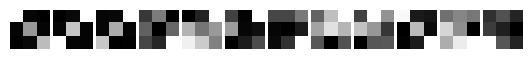

conv1: 6/10: 1 13 : (9, 9) -> (12, 3, 3)


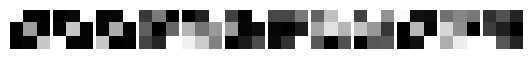

conv1: 7/10: 0 14 : (9, 9) -> (12, 3, 3)


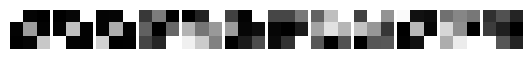

conv1: 7/10: 1 15 : (9, 9) -> (12, 3, 3)


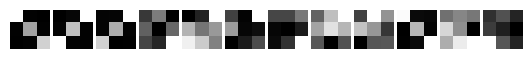

conv1: 8/10: 0 16 : (9, 9) -> (12, 3, 3)


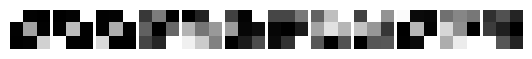

conv1: 8/10: 1 17 : (9, 9) -> (12, 3, 3)


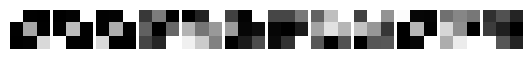

conv1: 9/10: 0 18 : (9, 9) -> (12, 3, 3)


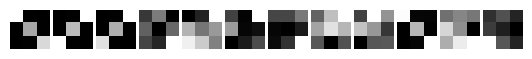

conv1: 9/10: 1 19 : (9, 9) -> (12, 3, 3)


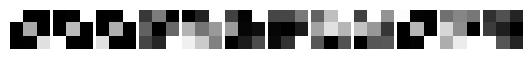

{'ref': <spikeml.core.base.Chain object at 0x0000015F619364A0>, 'context': <spikeml.core.runner.Context object at 0x0000015F61936470>}


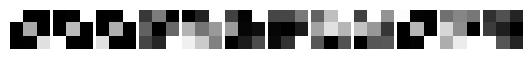

0.133,-0.0882,-0.0891,,,-0.129,-0.126,0.173,,,-0.0942,-0.0938,0.143,,,-0.000658,0.000841,-0.00186,,,-0.00124,-0.000896,0.00129,,,-0.000786,-0.00185,0.00247,,,-0.000817,-0.000813,4.82e-05,,,-0.00077,-4.01e-05,0.000467,,,-0.000335,0.00182,0.000593,,,0.1,-0.0743,-0.0749,,,-0.00064,-0.000413,-0.000566,,,-0.000948,-0.000208,-0.00123
-0.0882,0.0583,-0.0883,,,-0.128,0.0922,-0.128,,,-0.0941,0.0673,-0.0944,,,0.000246,-0.00188,0.000363,,,0.000541,-7.97e-05,0.000285,,,0.000764,-0.0018,-0.00164,,,-0.00191,-0.00202,-0.00156,,,-0.000256,0.000224,-0.000115,,,0.00112,0.000629,-0.000471,,,-0.0773,0.0511,-0.0761,,,0.000416,-0.000326,-0.00181,,,-0.000674,-0.00136,-0.00208
-0.0887,-0.0879,0.106,,,0.173,-0.128,-0.128,,,0.113,-0.0957,-0.0951,,,-0.000373,-0.00105,0.0037,,,0.00114,0.000774,4.09e-05,,,-0.0019,-0.00143,-0.000596,,,-0.00185,-0.00115,0.00234,,,-0.000859,-0.00155,-0.00091,,,-0.00109,-0.000102,-8.51e-05,,,-0.0769,-0.0742,0.102,,,-4.17e-06,0.000642,0.000846,,,0.00377,-9.45e-05,-0.00124


(2, 12, 3, 3)


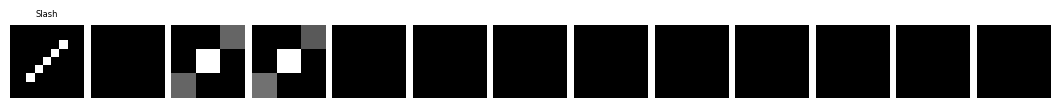

--------------------


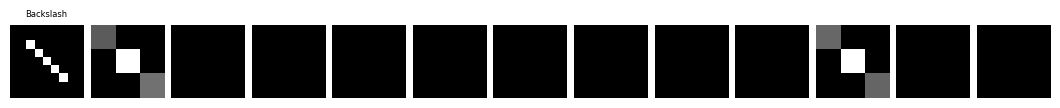

--------------------


In [33]:
def make_conv1_(kx=6):
    N = len(labels)*kx
    K = 3
    M = RateConnector((N,K,K), params=ConnectorParams(mean=0, sd=.001, t_p=5, t_d=10, cmin=-10, cmax=10, topk=2))
    conv = Conv2d(M, params=NNParams(t_b=5, t_bn=50, e_b=20))
    print('M:', M.shape)
    print(M.params.fmt())
    print(conv.params.fmt())
    nn = Chain([conv])
    return nn


def _callback(_, ref, x, y, context):
    #print(ll_2.M.M)
    title = f'conv1: {context.epoch}/{context.epochs}: {context.idx} {context.t} {y.shape}'
    #if context.idx==0:
    print(f'conv1: {context.epoch}/{context.epochs}: {context.idx} {context.t} : {x.shape} -> {y.shape}')
    show_kernels(ref[0].M.M)
    #show_kmaps(x, y, labels__[context.idx], batch=context.batch, debug=False)    
    #xdisplay(Markup('dM:', ref[0].M.dM))
    #xdisplay(Markup('M:', ref[0].M.M))
    #show_img(ll_2.M.M, title=title)

xx, yy, labels = _test_dataset()
print('xx:', xx.shape)
#xx__ = np.repeat(xx, 2, axis=0)
#labels__ = [label for label in labels_ for _ in range(10)]
#print('xx__:', xx__.shape)
dataset_cv1 = SimpleDataset(xx)
loader_cv1 = DataLoader(dataset_cv1, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)
      
conv1 = make_conv1_()  
runner_cv1 = DataRunner(conv1, loader_cv1, epochs=10, plot=False, log_step=-1, log_epoch=-1, callback=_callback)
#show_kernels(conv1[0].M.M)
result_cv1_ = runner_cv1.run(options={'log.modules': False})
print(result_cv1_)
#show_img(nn2_['ll_2'], title='ll_2: final')
show_kernels(conv1[0].M.M)
xdisplay(Markup('M:', conv1[0].M.M))
#ym = conv1(xx[0], Context(batch=False))
#show_kmaps(xx[0], ym, labels[0], batch=False, debug=False)    
ym = conv1(xx, Context(batch=True))
print(ym.shape)
show_kmaps(xx, ym, labels, batch=True, debug=True)    


In [34]:
xx, yy, labels = _test_dataset4()
print('xx:', xx.shape)
xx_ = xx.reshape(xx.shape[0], -1)
print('xx_:', xx_.shape)
xxm = xx_.mean(axis=1, keepdims=True)
print('xxm:', xxm.shape)
xxm = xx.reshape(xx.shape[0], -1).mean(axis=1, keepdims=True)
print('xxm:', xxm.shape)
xx = xx - xxm[:,None,None]

xx: (4, 9, 9)
xx_: (4, 81)
xxm: (4, 1)
xxm: (4, 1)


In [ ]:
from spikeml.utils.vector import normalize_all
from spikeml.cv.img_util import show_kmaps, show_tiles
from spikeml.core.layer import LayerNorm

xx, yy, labels = _test_dataset4()
#xx_ = normalize_all(xx, axis=(1,2))
#print(xx_)
xx_ = NormalizeLayer(axis=(1,2))(xx, Context(batch=True))
xx__ = LayerNorm(mean_only=True)(xx_, Context(batch=True))
xx___ = NormalizeLayer(axis=(1,2))(xx__, Context(batch=True))

# for i in range(xx.shape[0]):
#     print(i)
#     print(xx_[i])
#     print(xx__[i])
#     print(xx___[i])
    

xx: (2, 9, 9)
xx__: (2, 9, 9)
xx_: (2, 9, 9)


-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,0.938,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333
-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,-0.0617,,,-0.333,-0.333,-0.333,0.667,0.667,0.667,-0.333,-0.333,-0.333


M: (4, 3, 3)
ConnectorParams:g=1,e_err=5,vmin=-1.0,vmax=1.0,k_p=2,k_n=2,t_cp=10,t_cn=10,t_p=10.0,t_d=20.0,c_in=0,c_out=0,cmin=-2.0,cmax=2.0,mean=0.0,sd=0.001,topk=1
NNParams:t_b=5.0,t_bn=50.0,e_b=20.0,g=1,e_err=5,vmin=-1.0,vmax=1.0
DONE! ----------------------------------------
(2, 4, 3, 3)


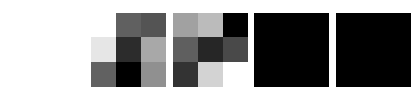

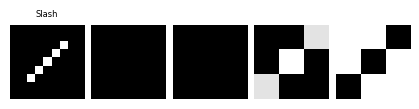

--------------------


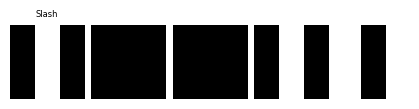

--------------------


In [90]:
from spikeml.cv.img_util import show_kmaps, show_tiles
from spikeml.core.layer import LayerNorm

xx, yy, labels = _test_dataset2b()
print('xx:', xx.shape)
#xx *= .5
xx__ = np.repeat(xx, 1, axis=0)
labels__ = [label for label in labels_ for _ in range(10)]
print('xx__:', xx__.shape)
#xx_ = NormalizeLayer()(xx, Context(batch=True))
xx_ = LayerNorm(mean_only=True, gamma=1, params=LayerParams(vmin=-1, vmax=1))(xx__, Context(batch=True))
print('xx_:', xx_.shape)
#print(xx_)
xdisplay(xx_)
dataset_cv1 = SimpleDataset(xx_)
loader_cv1 = DataLoader(dataset_cv1, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)
      
      
def make_conv1_(kx=6):
    N = len(labels)*kx
    K = 3
    M = RateConnector((N,K,K), params=ConnectorParams(mean=0, sd=.001, t_p=10, t_d=20, cmin=-2, cmax=2, topk=1, vmin=-1, vmax=1))
    conv = Conv2d(M, params=NNParams(t_b=5, t_bn=50, e_b=20, vmin=-1, vmax=1))
    print('M:', M.shape)
    print(M.params.fmt())
    print(conv.params.fmt())
    #LayerNorm(mean_only=True), 
    nn = Chain([conv])
    return nn


def _callback(_, ref, x, y, context):
    #print(ll_2.M.M)
    title = f'conv1: {context.epoch}/{context.epochs}: {context.idx} {context.t} {y.shape}'
    #if context.idx==0:
    return
    print(f'conv1: {context.epoch}/{context.epochs}: {context.idx} {context.t} : {x.shape} -> {y.shape}', '-'*40)
    conv = ref[0]
    show_kernels(conv.M.M)
    xdisplay(Markup('M:', conv.M.M))
    show_kernels(conv.M.dM.reshape(conv.M.shape), normalize=True)
    xdisplay(Markup('dM:', conv.M.dM.reshape(conv.M.shape)))
    show_kmaps(x, conv._y, labels[context.idx], batch=context.batch, debug=True)    
    show_kmaps(x, y, labels[context.idx], batch=context.batch, debug=True)    
    #show_img(ll_2.M.M, title=title)
    
conv1 = make_conv1_(kx=2)  

runner_cv1 = DataRunner(conv1, loader_cv1, epochs=20, plot=False, log_step=-1, log_epoch=-1, callback=_callback)
#show_kernels(conv1[0].M.M)
#xdisplay(conv1[0].M.M)
result_cv1_ = runner_cv1.run(options={'log.modules': False})
#print(result_cv1_)
#show_img(nn2_['ll_2'], title='ll_2: final')
#xdisplay(Markup('M:', conv1[0].M.M))
#ym = conv1(xx[0], Context(batch=False))
#show_kmaps(xx[0], ym, labels[0], batch=False, debug=False)    
#xx_ = NormalizeLayer()(xx, Context(batch=True))
xx_ = LayerNorm(mean_only=True, gamma=1, params=LayerParams(vmin=-1, vmax=1))(xx, Context(batch=True))
#xx_ *= 4
#xx_ = np.clip(xx_, -1, 1)
ym = conv1(xx_, Context(batch=True))
print('DONE!', '-'*40)
print(ym.shape)
show_kmaps(xx_, ym, labels__, conv1[0].M.M, batch=True, debug=True, normalize=True)    


# Digits Dataset classification (10)

(1797, 64)


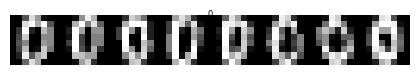

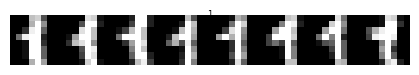

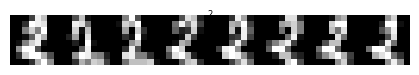

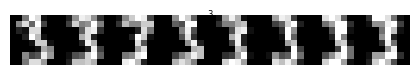

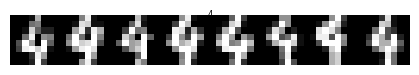

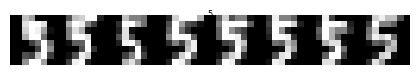

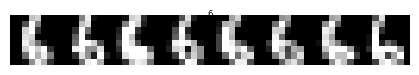

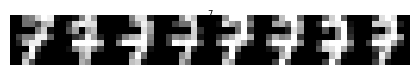

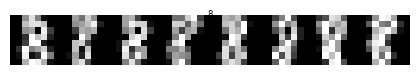

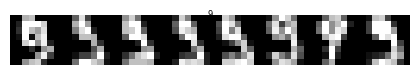

In [37]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt
import numpy as np

digits = load_digits()

print(digits.data.shape)
X = digits.images   # shape: (1797, 8, 8)
y = digits.target   # shape: (1797,)

def show_img_dataset(X, y, labels=None, nsamples=6, ncols=None, figsize=None):
    y_ = np.unique(y).tolist()
    if ncols is None:
        ncols = nsamples
    if figsize is None:
        figsize=(ncols, 1)
    for label in y_:
        ii = np.where(y == label)[0]
        if ii.shape[0]==0:
            continue
        ii = ii[:min(ii.shape[0], nsamples)]
        stitle = f'{labels[label]} ({label})' if labels is not None else  f'{label}'
        show_imgs(X[ii], ncols=nsamples, suptitle=stitle, title_size=8, figsize=figsize)

show_img_dataset(X, y, nsamples=8, figsize=(8*.5, .5))

In [38]:
yy = digits.target
yy_ = one_hot(yy, 10)
xx_ = digits.data
dataset_2 = SimpleDataset(xx_, yy_)
loader_2 = DataLoader(dataset_2, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, nclasses):
    N = nclasses*4
    nl_1 = NormalizeLayer(scale=3)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((nclasses, N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

nn_2 = make_nn(xx_, 10)
    
runner_2 = DataRunner(nn_2, loader_2, epochs=10, plot=False, log_step=-1, log_epoch=1, callback=None)#_callback)
result_2 = runner_2.run(options={'log.modules': False, 'log.connector': False})
#print(result_2)
show_kernels(nn_2['ll_1'].M.M, xx[0].shape, figsize=(20, 4))
show_img(nn_2['ll_2'].M.M)
#print(nn_2['ll_2'].M.M)


epoch = 0:


AxisError: axis 1 is out of bounds for array of dimension 1

In [ ]:
from  spikeml.core.metrics import eval, print_pred


{'accuracy': 0.27378964941569284, 'confusion_matrix': array([[177,   1,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 41, 137,   0,   4,   0,   0,   0,   0,   0,   0],
       [ 97,  72,   3,   5,   0,   0,   0,   0,   0,   0],
       [ 11,  23,   0, 149,   0,   0,   0,   0,   0,   0],
       [ 37, 142,   0,   0,   2,   0,   0,   0,   0,   0],
       [114,  62,   0,   6,   0,   0,   0,   0,   0,   0],
       [107,  49,   0,   0,   1,   0,  24,   0,   0,   0],
       [ 85,  93,   0,   1,   0,   0,   0,   0,   0,   0],
       [ 92,  54,   0,  26,   2,   0,   0,   0,   0,   0],
       [ 95,   6,   0,  79,   0,   0,   0,   0,   0,   0]])}
yy_pred: [0 1 0 ... 1 3 0]


,0,1,2,3,4,5,6,7,8,9
0,177,1,0,0,0,0,0,0,0,0
1,41,137,0,4,0,0,0,0,0,0
2,97,72,3,5,0,0,0,0,0,0
3,11,23,0,149,0,0,0,0,0,0
4,37,142,0,0,2,0,0,0,0,0
5,114,62,0,6,0,0,0,0,0,0
6,107,49,0,0,1,0,24,0,0,0
7,85,93,0,1,0,0,0,0,0,0
8,92,54,0,26,2,0,0,0,0,0
9,95,6,0,79,0,0,0,0,0,0


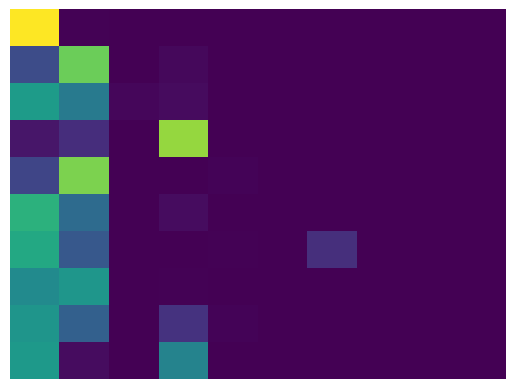

0: 0 ->0 
1: 1 ->1 
2: 2 ->0 
3: 3 ->3 
4: 4 ->1 
5: 5 ->3 
6: 6 ->0 
7: 7 ->0 
8: 8 ->0 
9: 9 ->0 
10: 0 ->0 
11: 1 ->1 
12: 2 ->1 
13: 3 ->3 
14: 4 ->1 
15: 5 ->1 
16: 6 ->1 
17: 7 ->1 
18: 8 ->1 
19: 9 ->0 
20: 0 ->0 
21: 1 ->0 
22: 2 ->1 
23: 3 ->3 
24: 4 ->1 
25: 5 ->1 
26: 6 ->6 
27: 7 ->0 
28: 8 ->0 
29: 9 ->0 
30: 0 ->0 
31: 9 ->3 
32: 5 ->0 
33: 5 ->0 
34: 6 ->1 
35: 5 ->1 
36: 0 ->0 
37: 9 ->0 
38: 8 ->0 
39: 9 ->3 
40: 8 ->0 
41: 4 ->1 
42: 1 ->1 
43: 7 ->1 
44: 7 ->0 
45: 3 ->3 
46: 5 ->1 
47: 1 ->1 
48: 0 ->0 
49: 0 ->0 
50: 2 ->0 
51: 2 ->0 
52: 7 ->0 
53: 8 ->1 
54: 2 ->0 
55: 0 ->0 
56: 1 ->1 
57: 2 ->1 
58: 6 ->6 
59: 3 ->1 
60: 3 ->3 
61: 7 ->0 
62: 3 ->3 
63: 3 ->3 
64: 4 ->1 
65: 6 ->6 
66: 6 ->0 
67: 6 ->0 
68: 4 ->1 
69: 9 ->1 
70: 1 ->1 
71: 5 ->0 
72: 0 ->0 
73: 9 ->0 
74: 5 ->1 
75: 2 ->0 
76: 8 ->1 
77: 2 ->0 
78: 0 ->0 
79: 0 ->0 
80: 1 ->1 
81: 7 ->1 
82: 6 ->6 
83: 3 ->3 
84: 2 ->0 
85: 1 ->1 
86: 7 ->0 
87: 4 ->1 
88: 6 ->1 
89: 3 ->3 
90: 1 ->1 
91: 3 ->3

In [ ]:
yy_prob, yy_pred, metrics = eval(nn_2, xx_, yy)
print(metrics)
print('yy_pred:', yy_pred)
#cm_norm = metrics['confusion_matrix'] / metrics['confusion_matrix'].sum(axis=1, keepdims=True)

digits_ = [ f'{i}' for i in range(0, 10) ]
cm = pd.DataFrame(metrics['confusion_matrix'], index=digits_, columns=digits_)
display(cm)
mshow(cm)

print_pred(xx_, yy, yy_pred, yy_prob)


# MNIST Dataset classification (10)

(70000, 784) (70000,)
(70000, 28, 28) (70000,)


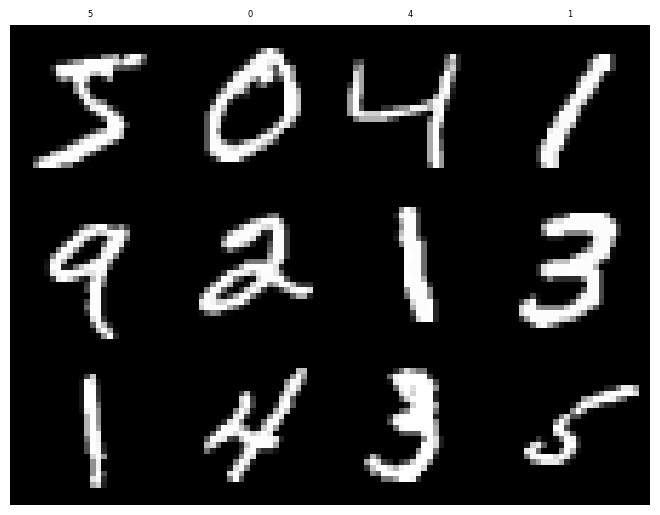

array([<Axes: title={'center': '5'}>, <Axes: title={'center': '0'}>, <Axes: title={'center': '4'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '9'}>, <Axes: title={'center': '2'}>,
       <Axes: title={'center': '1'}>, <Axes: title={'center': '3'}>, <Axes: title={'center': '1'}>,
       <Axes: title={'center': '4'}>, <Axes: title={'center': '3'}>, <Axes: title={'center': '5'}>], dtype=object)

In [ ]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', version=1, as_frame=False)

X = mnist.data        # shape (70000, 784)
y = mnist.target     # labels as strings
print(X.shape, y.shape)
y_ = y.astype(int) # Convert labels to int
X_ = X.reshape(-1, 28, 28)
print(X_.shape, y.shape)
#show_img(X_[0], title=f'{y[0]}', cmap=None, bgr=False, title_size=8, figsize=None)
show_imgs(X_[:12], titles=y[:12].tolist(), ncols=4, nrows=None, title_size=6, figsize=None, pad=0)



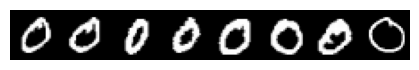

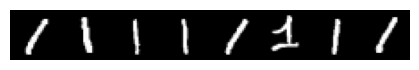

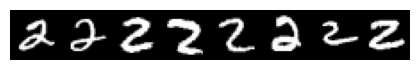

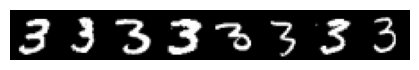

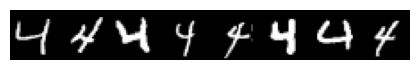

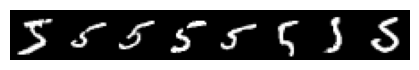

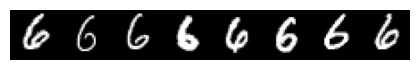

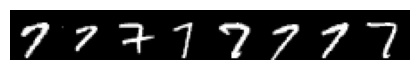

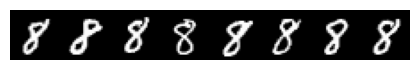

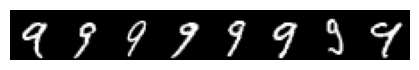

In [ ]:
show_img_dataset(X_, y_, nsamples=8, figsize=(8*.5, .5))

(1000, 784) (1000,)
epoch = 0:
epoch = 1:
epoch = 2:
epoch = 3:
epoch = 4:
epoch = 5:
epoch = 6:
epoch = 7:
epoch = 8:
epoch = 9:


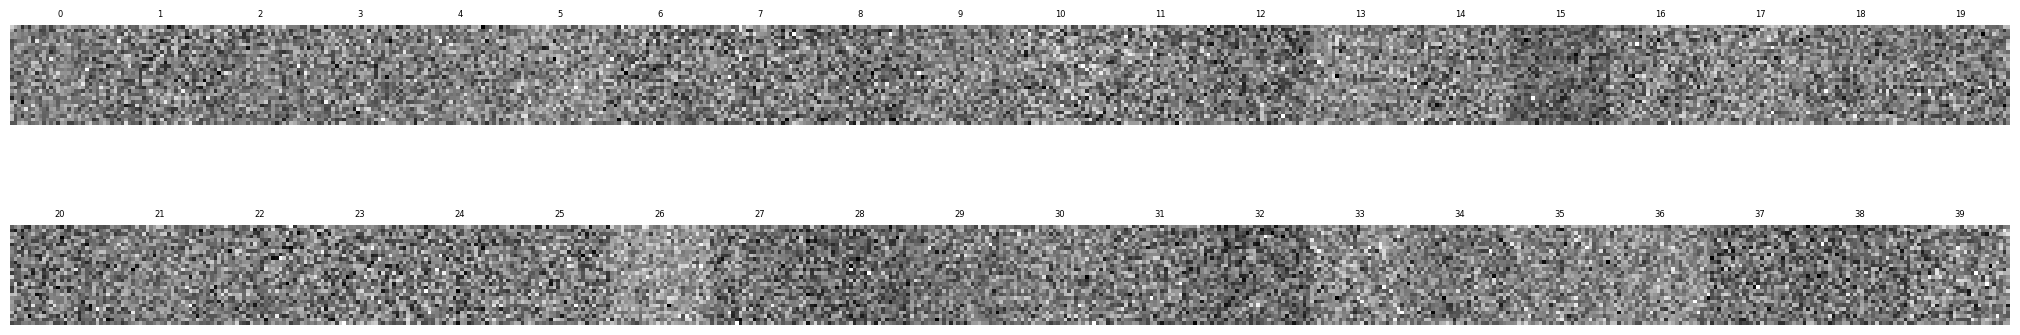

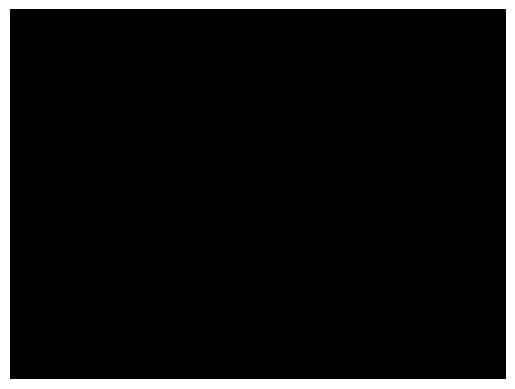

<Axes: >

In [ ]:
L=1000
_X, _y = X[0:L],y_[0:L]
yy_ = one_hot(_y, 10)
dataset_2 = SimpleDataset(_X, yy_)
print(_X.shape, _y.shape)
loader_2 = DataLoader(dataset_2, batch_size=-1, shuffle=False, num_workers=0, pin_memory=False, seed=SEED)

def make_nn(xx, nclasses):
    N = nclasses*4
    nl_1 = NormalizeLayer(scale=4)
    M_1 = RateConnector((N, xx[0].size), params=ConnectorParams(mean=0, sd=.001, t_p=1, t_d=1, cmin=-10, cmax=10))
    M_2 = RateConnector((nclasses, N), params=ConnectorParams(mean=.1, sd=0, t_p=1, t_d=10, cmin=-10, cmax=10))
    ll_1 = LinearLayer(M_1, params=NNParams(), name='ll_1')
    ll_2 = LinearLayer(M_2, params=NNParams(), name='ll_2', force=True) 
    #print(M_1.params.fmt())
    #print(ll_1.params.fmt())
    nn = Chain([nl_1, ll_1, ll_2])
    return nn

nn_2 = make_nn(_X, 10)
    
runner_2 = DataRunner(nn_2, loader_2, epochs=10, plot=False, log_step=-1, log_epoch=1, callback=None)#_callback)
result_2 = runner_2.run(options={'log.modules': False, 'log.connector': False})
#print(result_2)
show_kernels(nn_2['ll_1'].M.M, X_[0].shape, figsize=(20, 4))
show_img(nn_2['ll_2'].M.M)
#print(nn_2['ll_2'].M.M)



{'accuracy': 0.097, 'confusion_matrix': array([[ 97,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [116,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 99,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 93,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [105,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 92,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 94,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [117,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [ 87,   0,   0,   0,   0,   0,   0,   0,   0,   0],
       [100,   0,   0,   0,   0,   0,   0,   0,   0,   0]])}


,0,1,2,3,4,5,6,7,8,9
0,97,0,0,0,0,0,0,0,0,0
1,116,0,0,0,0,0,0,0,0,0
2,99,0,0,0,0,0,0,0,0,0
3,93,0,0,0,0,0,0,0,0,0
4,105,0,0,0,0,0,0,0,0,0
5,92,0,0,0,0,0,0,0,0,0
6,94,0,0,0,0,0,0,0,0,0
7,117,0,0,0,0,0,0,0,0,0
8,87,0,0,0,0,0,0,0,0,0
9,100,0,0,0,0,0,0,0,0,0


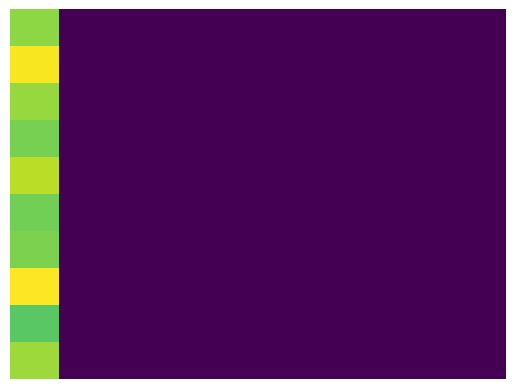

0: 0 ->0 
1: 1 ->0 
2: 2 ->0 
3: 3 ->0 
4: 4 ->0 
5: 5 ->0 
6: 6 ->0 
7: 7 ->0 
8: 8 ->0 
9: 9 ->0 
10: 0 ->0 
11: 1 ->0 
12: 2 ->0 
13: 3 ->0 
14: 4 ->0 
15: 5 ->0 
16: 6 ->0 
17: 7 ->0 
18: 8 ->0 
19: 9 ->0 
20: 0 ->0 
21: 1 ->0 
22: 2 ->0 
23: 3 ->0 
24: 4 ->0 
25: 5 ->0 
26: 6 ->0 
27: 7 ->0 
28: 8 ->0 
29: 9 ->0 
30: 0 ->0 
31: 9 ->0 
32: 5 ->0 
33: 5 ->0 
34: 6 ->0 
35: 5 ->0 
36: 0 ->0 
37: 9 ->0 
38: 8 ->0 
39: 9 ->0 
40: 8 ->0 
41: 4 ->0 
42: 1 ->0 
43: 7 ->0 
44: 7 ->0 
45: 3 ->0 
46: 5 ->0 
47: 1 ->0 
48: 0 ->0 
49: 0 ->0 
50: 2 ->0 
51: 2 ->0 
52: 7 ->0 
53: 8 ->0 
54: 2 ->0 
55: 0 ->0 
56: 1 ->0 
57: 2 ->0 
58: 6 ->0 
59: 3 ->0 
60: 3 ->0 
61: 7 ->0 
62: 3 ->0 
63: 3 ->0 
64: 4 ->0 
65: 6 ->0 
66: 6 ->0 
67: 6 ->0 
68: 4 ->0 
69: 9 ->0 
70: 1 ->0 
71: 5 ->0 
72: 0 ->0 
73: 9 ->0 
74: 5 ->0 
75: 2 ->0 
76: 8 ->0 
77: 2 ->0 
78: 0 ->0 
79: 0 ->0 
80: 1 ->0 
81: 7 ->0 
82: 6 ->0 
83: 3 ->0 
84: 2 ->0 
85: 1 ->0 
86: 7 ->0 
87: 4 ->0 
88: 6 ->0 
89: 3 ->0 
90: 1 ->0 
91: 3 ->0

In [ ]:
yy_prob, yy_pred, metrics = eval(nn_2, _X, _y)
print(metrics)
#cm_norm = metrics['confusion_matrix'] / metrics['confusion_matrix'].sum(axis=1, keepdims=True)

digits_ = [ f'{i}' for i in range(0, 10) ]
cm = pd.DataFrame(metrics['confusion_matrix'], index=digits_, columns=digits_)
display(cm)
mshow(cm)

print_pred(_X, yy, yy_pred, yy_prob)


In [ ]:
def tiles(a, K, S):
    tiles = sliding_window_view(a, (K, K))
    return tiles[::S, ::S]

print(X_.shape)

Xs=tiles(X_[0], K=9, S=9)
print(Xs.shape)

Xs_ = Xs.reshape(-1, *Xs.shape[2:])
Xs__ = Xs_.reshape(Xs_.shape[0], -1)
print(Xs.shape, Xs_.shape, Xs__.shape)
show_imgs(Xs_, titles=None, ncols=Xs.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)



# Interpretability

In [ ]:
def predictors(M, xx, yy, labels, pp=None, jj=None, debug=False):
    eps = 0.00001
    if pp is None:
        pp = [.1*k for k in range(1,10)]
    ny = len(labels)
    cm = np.zeros((ny, len(pp), M.shape[0], 2, 2), dtype=int)
    ce = np.zeros((ny, M.shape[0]), dtype=float)
    if jj is None:
        jj = range(0, M.shape[0])
    predictors_ = np.array((ny,len(pp), M.shape[0]), dtype=bool)
    zy = propagate_batch(M, xx)
    zy_ = np.clip(zy, eps, 1-eps)
    Zy = np.zeros((ny, M.shape[0]), dtype=float)
    np.add.at(Zy, yy, zy)
    counts = np.bincount(yy, minlength=ny)
    Zy = np.divide(Zy, counts[:, None],
        out=np.zeros_like(Zy, dtype=float),
        where=counts[:, None] > 0
    )
    print(Zy)
    for i in range(0, zy.shape[0]):
        lb = yy[i]
        y = zy[i]
        if debug:
            print(f'{i}:', 'target:', lb, labels[lb], 'y:', y, ':') 

        for k in range(0, len(pp)):
            p = pp[k]
            #np.where(yy[i] > p)[0]
            for j in jj:
                yj = y[j]
                pred = yj>=p
                if pred:
                    for lb_ in range(0, ny):
                        if lb_==lb:
                            cm[lb,k,j,0,0] += 1 #TP 
                            #if debug:
                            #    print('  TP:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb,k,j].tolist())
                        else:
                            cm[lb_,k,j,1,0] += 1  #FP 
                            #if debug:
                            #    print('  FP:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb_,k,j].tolist())
                else:
                    for lb_ in range(0, ny):
                        if lb_==lb:
                            cm[lb,k,j,0,1] += 1  #FN
                            #if debug:
                            #    print('  FN:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb,k,j].tolist())
                        else:
                            cm[lb_,k,j,1,1] += 1  #TN                            
                            #if debug:
                            #    print('  TN:', 'j:', j, 'yj:', yj, 'p:', p, 'pred:', lb_, labels[lb_], 'cm:', cm[lb_,k,j].tolist())
        for j in jj:
            y_ = zy_[i]
            for lb_ in range(0, ny):
                if lb_==lb:
                    ce[lb_,j] -= math.log(y_[j])
                else:
                    ce[lb_,j] -= math.log(1-y_[j])
    ce /= xx.shape[0]
    acc = np.zeros((ny, len(pp), M.shape[0]), dtype=float)
    prec = np.zeros((ny, len(pp), M.shape[0]),  dtype=float)
    recal = np.zeros((ny, len(pp), M.shape[0]), dtype=float)
    for i in range(0, ny):
        lb = yy[i]
        #if debug:
        #    print( f'{i}:', 'target:',  lb, labels[lb]) 
        for k in range(0, len(pp)):
        #    if debug:
        #        print( f'  {k}: p:', pp[k]) 
            for j in jj:
                acc[lb,k,j] = float(cm[lb,k,j,0,0] + cm[lb,k,j,1,1])/xx_.shape[0]
                n = cm[lb,k,j,0,0] + cm[lb,k,j,1,0]
                prec[lb,k,j] = float(cm[lb,k,j,0,0])/n if n>0 else 0
                n = cm[lb,k,j,0,0] + cm[lb,k,j,0,1]
                recal[lb,k,j] = float(cm[lb,k,j,0,0])/n if n>0 else 0
        #        if debug:
        #            print('    j:', j, 'acc:', acc[lb, k, j],  'prec:', prec[lb, k, j], 'recal:', recal[lb, k, j])

    predictor_pacc = np.argmax(acc, -1)  
    predictor_pprec = np.argmax(prec, -1)  
    predictor_precal = np.argmax(recal, -1)  
    best_pacc = np.max(acc, -1)
    best_pprec = np.max(prec, -1)
    best_precal = np.max(recal, -1)
    
    K = 3
    iacc = np.argsort(acc, -1)[-K:]

    best_acc = np.max(best_pacc, 1)
    best_acc_p = np.argmax(best_pacc, 1)
    L = np.arange(ny)
    predictor_acc = predictor_pacc[L,best_acc_p]
    print(predictor_pacc.shape, best_acc_p.shape, predictor_acc.shape)
    
    best_prec = np.max(best_pprec, 1)
    best_prec_p = np.argmax(best_pprec, 1)
    predictor_prec = predictor_pprec[L,best_prec_p]

    best_recal = np.max(best_precal, 1)
    best_recal_p = np.argmax(best_precal, 1)
    predictor_recal = predictor_precal[L,best_recal_p]

    predictor_ce = np.argmin(ce, 1)
    best_ce = np.min(ce, 1) 


    return {'ny': ny, 'cm': cm, 'pp': pp, 'acc': acc, 'prec': prec, 'recal': recal,
            'predictor_pacc': predictor_pacc, 'predictor_pprec': predictor_pprec, 'predictor_precal': predictor_precal,
            'predictor_acc': predictor_acc, 'predictor_prec': predictor_prec, 'predictor_recal': predictor_recal,
            'best_acc': best_acc, 'best_prec': best_prec, 'best_recal': best_recal,
            'best_pacc': best_pacc, 'best_pprec': best_pprec, 'best_precal': best_precal,
            'best_acc_p': best_acc_p, 'best_prec_p': best_prec_p, 'best_recal_p': best_recal_p,
            'ce': ce, 'predictor_ce': predictor_ce, 'best_ce': best_ce}


xx_ = normalize_all(xx, 2)*3

print(xx.shape, xx_.shape)
for i in range(0, xx_.shape[0]):
    y = propagate(M, xx_[i])
    print(f'{i}:', dd[i]['id'], yy[i], y)

print(yy)
print(labels)
metrics = predictors(M, xx_, yy, labels, pp=[.5], debug=True)

for j in range(0, M.shape[0]):
    print('cm:', j, metrics['cm'][:,0,j].tolist())
#print(metrics['ce'])
print('predictor_acc:', metrics['predictor_acc'].tolist())
for i in range(0, metrics['best_acc'].shape[0]):
    print(labels[i], '; predictor_acc:', metrics['predictor_acc'][i].tolist(), '; best_acc:', metrics['best_acc'][i].tolist())
for i in range(0, metrics['ce'].shape[0]):
    print(labels[i], 'ce:', metrics['ce'][i])
for i in range(0, metrics['ce'].shape[0]):
    print(labels[i], 'predictor_ce:', metrics['predictor_ce'][i], 'best_ce:', metrics['best_ce'][i])
#print(nn.shape)
#print(nn)

predictors = metrics['predictor_acc']
print(predictors)
kernels = [M[i].reshape(xx[0].shape) for i in range(0, predictors.shape[0]) ]
show_imgs(kernels, ncols=min(len(Y), 10), title_size=6, titles=gg)


(4, 8, 8) (4, 8, 8)


d:\git\rd\dynaspike\nb\tests\spikeml\cv\../../../../src\spikeml\utils\vector.py:242: RuntimeWarning: invalid value encountered in divide
  a = a / n[:,None]


NameError: name 'propagate' is not defined

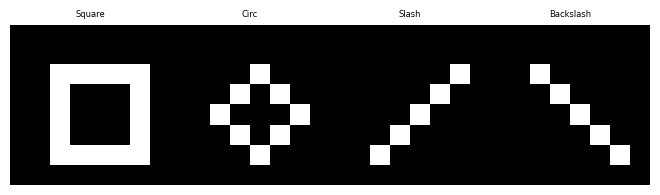

{'accuracy': 1.0, 'precision': 1.0, 'recall': 1.0, 'precision_per_class': array([1., 1., 1., 1.]), 'recall_per_class': array([1., 1., 1., 1.]), 'cm': array([[1, 0, 0, 0],
       [0, 1, 0, 0],
       [0, 0, 1, 0],
       [0, 0, 0, 1]])}


In [ ]:
def predict(xx, M, metrics, d2=True, predictor='acc'):
    yy = propagate_batch(M, xx, d2=True)
    pred = None
    if predictor=='acc':
        predictor = metrics['predictor_acc']
        p = metrics['best_acc_p']
        #print(predictor)
        #print(yy)
        ny = metrics['ny']
        pred_ = yy[:, predictor]
        pred = np.argmax(pred_, 1)
        #print(pred_)
        #print(pred)
    elif predictor=='ce':
        predictor = metrics['predictor_ce']
    else:
        return None
    return pred

    
def eval(xx, yy, M, metrics, d2=True, predictor='acc'):
    n = 0
    pred = predict(xx, M, metrics, d2, predictor) 
    acc = (pred==yy).mean()
    C = metrics['ny']
    precision_per_class = np.zeros(C)
    recall_per_class = np.zeros(C)
    cm = np.zeros((C, C), dtype=int)
    np.add.at(cm, (yy, pred), 1)
    for i, c in enumerate(range(C)):
        tp = np.sum((pred == c) & (yy == c))
        fp = np.sum((pred == c) & (yy != c))
        fn = np.sum((pred != c) & (yy == c))
        tn = np.sum((pred != c) & (yy != c))
        precision_per_class[i] = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        recall_per_class[i]    = tp / (tp + fn) if (tp + fn) > 0 else 0.0

    precision = precision_per_class.mean()
    recall    = recall_per_class.mean()
    metrics = {
        'accuracy': acc,
        'precision': precision,
        'recall': recall,
        'precision_per_class': precision_per_class,
        'recall_per_class': recall_per_class,
        'cm': cm
    }
    return metrics

pred = predict(xx_, M, metrics)
show_imgs(xx_, ncols=min(pred.shape[0], 10), title_size=6, titles=[gg[pred[i]] for i in range(pred.shape[0])])

metrics_ = eval(xx_, yy, M, metrics)
print(metrics_)

(2, 28, 28)
pca.explained_variance_ratio_: [1.00000000e+00 1.52179488e-31]
pca.singular_values_: [1.53000000e+03 5.96855898e-13]
pca.components_ [[ 3.90101894e-16 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]
 [ 1.00000000e+00 -0.00000000e+00 -0.00000000e+00 ... -0.00000000e+00
  -0.00000000e+00 -0.00000000e+00]]


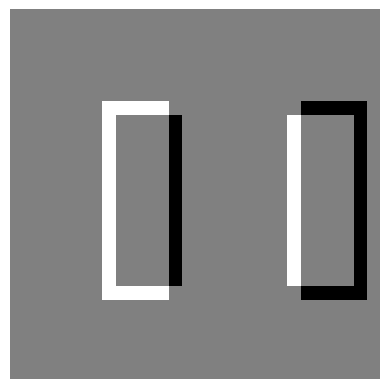

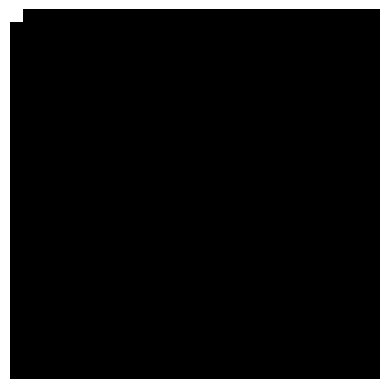

In [ ]:
from sklearn.decomposition import PCA

ds = np.array([a, a1]) #, ra
print(ds.shape)
pca = PCA(n_components=2)
pca.fit(ds.reshape(ds.shape[0], -1))

print('pca.explained_variance_ratio_:', pca.explained_variance_ratio_)
print('pca.singular_values_:', pca.singular_values_)
print('pca.components_', pca.components_)
for i in range(0, pca.components_.shape[0]):
    eimg = pca.components_[i].reshape(a.shape)
    show_img(eimg)


In [ ]:
A=Xs__
A_ = A[:, :, None] * A[:, None, :]
print(A.shape, Xs__.shape)

show_imgs(A_, titles=None, ncols=A_.shape[0], nrows=Xs.shape[1], title_size=6, figsize=(5,5), pad=.01)
